# Análise do Mini Índice WIN com foco em Gap

- gap de abertura;
- comportamento intraday após o gap;
- influência da janela de pré-close do dia anterior;
- criação de tabelas derivadas para análise estatística e machine learning.

- Qual a frequência de gap positivo e negativo?
- Quando o gap costuma fechar?
- O comportamento dos últimos 15 minutos do pregão anterior ajuda a prever o dia seguinte?
- Quais features fazem sentido para modelos supervisionados sem lookahead bias?


## 1. Configuração do estudo

Nesta etapa definimos os parâmetros principais do notebook: caminho do arquivo, tamanho da janela de pré-close, janelas de fill, bins de gap e horizontes de retorno.

Leitura rápida dos parâmetros:

- `JANELA_ATR = 14`: usa os últimos 14 dias para calcular o ATR médio.
- `JANELAS_FORWARD = [5, 15, 30]`: mede o retorno do preço 5, 15 e 30 minutos após a abertura.
- `JANELAS_FILL = [5, 10, 20, 30]`: mede se o gap fechou até 5, 10, 20 ou 30 minutos após a abertura.
- `ALVOS_ALPHA = [0.3, 0.5, 0.7, 1.0]`: cria alvos de fill parcial em 30%, 50%, 70% e 100% do gap.
- `BINS_GAP = [...]`: separa os gaps em faixas para resumir estatísticas.
- `MINIMO_LINHAS_TREINO = 150`: evita treinar modelo com pouca amostra.
- `np.inf`: significa infinito. Aqui ele serve para criar uma faixa sem limite, por exemplo `200 até infinito`.


In [105]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
plt.style.use('ggplot')

In [106]:
# Habilita tabelas interativas para todos os DataFrames do Pandas no Colab
# Aumentamos o max_columns para suportar a tabela de gaps que possui 29 colunas

# Configura o limite de colunas para as tabelas interativas

print("Tabelas interativas habilitadas (Limite: 50 colunas). Execute as células de visualização abaixo.")

Tabelas interativas habilitadas (Limite: 50 colunas). Execute as células de visualização abaixo.


In [107]:
# ─── CAMINHO DOS DADOS ───
CAMINHO_DADOS = 'https://raw.githubusercontent.com/Phelipe-J/win_dataset_0001/refs/heads/main/WIN%24N_M1_202010151149_202605141831.csv'

# CAMINHO_DADOS = Path('WIN$N_M1.csv')

# Pasta onde as bases derivadas serão salvas.
PASTA_SAIDA = Path('outputs_gap_win')
PASTA_SAIDA.mkdir(exist_ok=True)

# Quantidade de minutos usados para resumir o final do pregão anterior.
MINUTOS_PRECLOSE = 15

# Janela do ATR diário. ATR é uma medida média de amplitude/volatilidade.
JANELA_ATR = 14

# Retornos futuros medidos a partir da abertura do dia.
JANELAS_FORWARD = [5, 15, 30]

# Janelas máximas para considerar que o gap fechou em um trade intraday.
JANELAS_FILL = [5, 10, 15, 20, 30]

# Percentuais do gap que serão usados como alvos parciais de fill.
ALVOS_ALPHA = [0.3, 0.5, 0.7, 1.0]

# Faixas de gap em pontos. np.inf significa infinito.
BINS_GAP = [-np.inf, -200, -150, -100, -50, 0, 50, 100, 150, 200, np.inf]

# Quantidade mínima de linhas para aceitar o treino do modelo.
MINIMO_LINHAS_TREINO = 150

print(f'Arquivo/Url configurado: {CAMINHO_DADOS.resolve() if isinstance(CAMINHO_DADOS, Path) else CAMINHO_DADOS}')
print(f'Pasta de saída: {PASTA_SAIDA.resolve()}')


Arquivo/Url configurado: https://raw.githubusercontent.com/Phelipe-J/win_dataset_0001/refs/heads/main/WIN%24N_M1_202010151149_202605141831.csv
Pasta de saída: C:\Users\rodrigo.silva\Pictures\UFG\DB FIN\outputs_gap_win


## 2. Importação e padronização da base intraday

O arquivo veio no formato exportado de plataforma de mercado, com colunas entre `<>` e separação por tabulação. Aqui nós:

- lemos a base corretamente com `sep='\t'`;
- renomeamos as colunas para nomes limpos;
- criamos o `datetime`;
- ordenamos temporalmente;
- validamos duplicidades e dados faltantes.


In [108]:
# O arquivo está separado por tabulação. Por isso usamos sep='\t'.
dados_brutos = pd.read_csv(CAMINHO_DADOS, sep='	')
dados_brutos.columns = [coluna.strip('<>').lower() for coluna in dados_brutos.columns]

# Padronizamos alguns nomes para deixar as colunas mais legíveis.
mapa_renomeacao = {
    'tickvol': 'tick_volume',
    'vol': 'volume',
    'spread': 'spread'
}
dados_brutos = dados_brutos.rename(columns=mapa_renomeacao)

base_intraday = dados_brutos.copy()

# Junta data e hora em uma única coluna temporal.
base_intraday['datetime'] = pd.to_datetime(
    base_intraday['date'] + ' ' + base_intraday['time'],
    format='%Y.%m.%d %H:%M:%S'
)
base_intraday = base_intraday.sort_values('datetime').reset_index(drop=True)

colunas_preco = ['open', 'high', 'low', 'close']
colunas_auxiliares = ['tick_volume', 'volume', 'spread']

# Garante que as colunas numéricas realmente sejam tratadas como números.
for coluna in colunas_preco + colunas_auxiliares:
    base_intraday[coluna] = pd.to_numeric(base_intraday[coluna], errors='coerce')

# session_date representa o dia de pregão sem a parte do horário.
base_intraday['session_date'] = base_intraday['datetime'].dt.normalize()
base_intraday['clock_time'] = base_intraday['datetime'].dt.time
base_intraday['minute'] = base_intraday['datetime'].dt.hour * 60 + base_intraday['datetime'].dt.minute

print('Shape intraday:', base_intraday.shape)
print('Período:', base_intraday['datetime'].min(), '->', base_intraday['datetime'].max())
print('Duplicidades de datetime:', base_intraday['datetime'].duplicated().sum())
print('Valores nulos principais:')
print(base_intraday[colunas_preco + colunas_auxiliares].isna().sum())

base_intraday.head()


Shape intraday: (766929, 13)
Período: 2020-10-15 11:49:00 -> 2026-05-14 18:31:00
Duplicidades de datetime: 0
Valores nulos principais:
open           0
high           0
low            0
close          0
tick_volume    0
volume         0
spread         0
dtype: int64


,date,time,open,high,low,close,tick_volume,volume,spread,datetime,session_date,clock_time,minute
0,2020.10.15,11:49:00,98565,98575,98530,98575,2373,9001,5,2020-10-15 11:49:00,2020-10-15,11:49:00,709
1,2020.10.15,11:50:00,98570,98625,98570,98600,5483,19111,5,2020-10-15 11:50:00,2020-10-15,11:50:00,710
2,2020.10.15,11:51:00,98595,98600,98535,98580,4572,17663,5,2020-10-15 11:51:00,2020-10-15,11:51:00,711
3,2020.10.15,11:52:00,98575,98620,98535,98615,3536,13143,5,2020-10-15 11:52:00,2020-10-15,11:52:00,712
4,2020.10.15,11:53:00,98620,98625,98575,98610,3729,13702,5,2020-10-15 11:53:00,2020-10-15,11:53:00,713


## 3. Sanidade temporal do pregão

Nem todo dia tem o mesmo número de barras. Isso pode ocorrer por horário estendido, mudanças de sessão, início parcial da amostra ou dias especiais. Antes de modelar qualquer coisa, conferimos a estrutura diária para evitar assumir horários fixos incorretos.


In [109]:
# Esta tabela ajuda a entender a estrutura de cada sessão.
agenda_diaria = (
    base_intraday.groupby('session_date')
    .agg(
        primeira_barra=('datetime', 'min'),
        ultima_barra=('datetime', 'max'),
        quantidade_barras=('datetime', 'size')
    )
    .assign(
        horario_abertura=lambda df: df['primeira_barra'].dt.strftime('%H:%M:%S'),
        horario_fechamento=lambda df: df['ultima_barra'].dt.strftime('%H:%M:%S')
    )
)

print('Quantidade de dias:', len(agenda_diaria))
print()
print('Distribuição de barras por dia:')
print(agenda_diaria['quantidade_barras'].describe())
print()
print('Horários de fechamento mais comuns:')
print(agenda_diaria['horario_fechamento'].value_counts().head(10))

agenda_diaria.head()


Quantidade de dias: 1388

Distribuição de barras por dia:
count    1388.000000
mean      552.542507
std        21.418824
min       325.000000
25%       535.000000
50%       565.000000
75%       565.000000
max       566.000000
Name: quantidade_barras, dtype: float64

Horários de fechamento mais comuns:
horario_fechamento
18:24:00    882
17:54:00    499
17:55:00      3
18:25:00      3
18:31:00      1
Name: count, dtype: int64


,primeira_barra,ultima_barra,quantidade_barras,horario_abertura,horario_fechamento
session_date,,,,,
2020-10-15,2020-10-15 11:49:00,2020-10-15 17:54:00,366,11:49:00,17:54:00
2020-10-16,2020-10-16 09:00:00,2020-10-16 17:54:00,535,09:00:00,17:54:00
2020-10-19,2020-10-19 09:00:00,2020-10-19 17:54:00,535,09:00:00,17:54:00
2020-10-20,2020-10-20 09:00:00,2020-10-20 17:54:00,535,09:00:00,17:54:00
2020-10-21,2020-10-21 09:00:00,2020-10-21 17:54:00,535,09:00:00,17:54:00


## 4. Funções auxiliares

As próximas análises exigem medidas que não vêm prontas do CSV, como tempo até o fill, fill por janela de tempo, retornos futuros após a abertura e métricas de excursão (`MFE` e `MAE`).

Leitura em português:

- `MFE` = excursão favorável máxima;
- `MAE` = excursão adversa máxima;
- retornos "forward" = retornos medidos alguns minutos depois da abertura;
- fill temporal = verificar se o gap fechou dentro de uma janela, como 5, 10, 20 ou 30 minutos.

Essas funções existem para evitar repetição de código e deixar a lógica mais fácil de revisar.


In [110]:
def primeiro_horario_que_bate(day_frame, condicao):
    """Retorna o primeiro horário em que a condição foi satisfeita."""
    acertos = day_frame.loc[condicao(day_frame)]
    if acertos.empty:
        return pd.NaT
    return acertos['datetime'].iloc[0]


def minutos_entre(inicio, fim):
    """Converte diferença de tempo para minutos."""
    if pd.isna(inicio) or pd.isna(fim):
        return np.nan
    return (fim - inicio).total_seconds() / 60.0


def calcular_retornos_forward(day_frame, preco_entrada, janelas):
    """Mede o retorno após N minutos a partir do preço de entrada."""
    resultados = {}
    fechamentos = day_frame['close'].reset_index(drop=True)
    for janela in janelas:
        if len(fechamentos) > janela:
            resultados[f'ret_{janela}m_from_open'] = fechamentos.iloc[janela] / preco_entrada - 1
        else:
            resultados[f'ret_{janela}m_from_open'] = np.nan
    return resultados


def lado_do_fill(gap_em_pontos):
    """Informa se o preço precisa subir ou cair para preencher o gap."""
    if gap_em_pontos > 0:
        return 'down_to_prev_close'
    if gap_em_pontos < 0:
        return 'up_to_prev_close'
    return 'flat'


def calcular_fills_temporais(dados_dia, fechamento_anterior, gap_em_pontos, janelas_fill):
    """Calcula se houve fill total dentro de cada janela após a abertura."""
    resultados = {}
    inicio = dados_dia['datetime'].iloc[0]

    for minutos in janelas_fill:
        janela = dados_dia.iloc[: min(len(dados_dia), minutos + 1)].copy()

        if gap_em_pontos > 0:
            horario_fill = primeiro_horario_que_bate(janela, lambda df: df['low'] <= fechamento_anterior)
        elif gap_em_pontos < 0:
            horario_fill = primeiro_horario_que_bate(janela, lambda df: df['high'] >= fechamento_anterior)
        else:
            horario_fill = inicio

        resultados[f'fill_ate_{minutos}m'] = int(pd.notna(horario_fill))
        resultados[f'tempo_fill_ate_{minutos}m'] = minutos_entre(inicio, horario_fill)

    return resultados


## 5. Base diária

Aqui transformamos a base de 1 minuto em uma visão diária com abertura (`open`), máxima (`high`), mínima (`low`) e fechamento (`close`), além de volume agregado e métricas de retorno e volatilidade.

Fórmulas principais desta etapa:

- amplitude do dia = `high - low`
- retorno fechamento contra fechamento anterior = `close_t / close_(t-1) - 1`
- retorno abertura até fechamento = `close_t / open_t - 1`
- `TR` = maior valor entre amplitude do dia, distância da máxima ao fechamento anterior e distância da mínima ao fechamento anterior
- `ATR_14` = média móvel de 14 períodos do `TR`

O objetivo desta base é resumir cada pregão em uma única linha.


In [111]:
# A base diaria resume cada sessão em uma Única linha.
base_diaria = (
    base_intraday.groupby('session_date')
    .agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        tick_volume=('tick_volume', 'sum'),
        volume=('volume', 'sum'),
        spread_mean=('spread', 'mean'),
        first_bar=('datetime', 'min'),
        last_bar=('datetime', 'max'),
        n_bars=('datetime', 'size')
    )
    .sort_index()
)

# Medidas básicas do dia.
base_diaria['range'] = base_diaria['high'] - base_diaria['low']
base_diaria['return_close_to_close'] = base_diaria['close'].pct_change()
base_diaria['return_open_to_close'] = base_diaria['close'] / base_diaria['open'] - 1
base_diaria['prev_close'] = base_diaria['close'].shift(1)
base_diaria['prev_high'] = base_diaria['high'].shift(1)
base_diaria['prev_low'] = base_diaria['low'].shift(1)
base_diaria['prev_range'] = base_diaria['range'].shift(1)

# True Range: maior deslocamento relevante do dia.
base_diaria['tr'] = np.maximum.reduce([
    base_diaria['high'] - base_diaria['low'],
    (base_diaria['high'] - base_diaria['prev_close']).abs(),
    (base_diaria['low'] - base_diaria['prev_close']).abs()
])

# ATR: média do true range ao longo de N pregões.
base_diaria['atr_14'] = base_diaria['tr'].rolling(JANELA_ATR).mean()

# Classificação simples da cor do dia.
base_diaria['day_direction'] = np.where(base_diaria['close'] > base_diaria['open'], 'green', np.where(base_diaria['close'] < base_diaria['open'], 'red', 'doji'))

base_diaria.head()


,open,high,low,close,tick_volume,volume,spread_mean,first_bar,last_bar,n_bars,range,return_close_to_close,return_open_to_close,prev_close,prev_high,prev_low,prev_range,tr,atr_14,day_direction
session_date,,,,,,,,,,,,,,,,,,,,
2020-10-15,98565,99730,98530,99045,1829254,7243736,5.0,2020-10-15 11:49:00,2020-10-15 17:54:00,366,1200,NaN,0.004870,NaN,NaN,NaN,NaN,NaN,NaN,green
2020-10-16,99340,99435,98280,98700,3214746,12868460,5.0,2020-10-16 09:00:00,2020-10-16 17:54:00,535,1155,-0.003483,-0.006443,99045.0,99730.0,98530.0,1200.0,1155.0,NaN,red
2020-10-19,99150,100170,98570,98940,3194968,12871081,5.0,2020-10-19 09:00:00,2020-10-19 17:54:00,535,1600,0.002432,-0.002118,98700.0,99435.0,98280.0,1155.0,1600.0,NaN,red
2020-10-20,99200,100970,99120,100930,3230176,12894073,5.0,2020-10-20 09:00:00,2020-10-20 17:54:00,535,1850,0.020113,0.017440,98940.0,100170.0,98570.0,1600.0,2030.0,NaN,green
2020-10-21,100500,101875,100280,100710,3480858,13984220,5.0,2020-10-21 09:00:00,2020-10-21 17:54:00,535,1595,-0.002180,0.002090,100930.0,100970.0,99120.0,1850.0,1595.0,NaN,green


## 6. Base de gap

Agora criamos a base principal do estudo. Cada linha representa um dia comparado ao fechamento do dia anterior.

Principais fórmulas:

- gap em pontos = `open_t - close_(t-1)`
- gap percentual = `(open_t - close_(t-1)) / close_(t-1)`
- gap normalizado pelo ATR = `gap / ATR`

Nesta versão, o fill principal deixa de ser "em qualquer momento do dia" e passa a ser analisado por janelas após a abertura:

- fill até 5 minutos;
- fill até 10 minutos;
- fill até 20 minutos;
- fill até 30 minutos.

Isso deixa o estudo mais alinhado com day trade.


In [112]:
linhas_gap = []
datas_pregao = base_diaria.index.tolist()

# Cada linha final representa o dia atual em relação ao fechamento do dia anterior.
for indice, data_pregao in enumerate(datas_pregao):
    if indice == 0:
        continue

    dados_dia = base_intraday.loc[base_intraday['session_date'] == data_pregao].copy()
    data_anterior = datas_pregao[indice - 1]
    fechamento_anterior = base_diaria.loc[data_anterior, 'close']
    abertura_atual = base_diaria.loc[data_pregao, 'open']
    maxima_atual = base_diaria.loc[data_pregao, 'high']
    minima_atual = base_diaria.loc[data_pregao, 'low']
    fechamento_atual = base_diaria.loc[data_pregao, 'close']

    gap_absoluto = abertura_atual - fechamento_anterior
    gap_percentual = gap_absoluto / fechamento_anterior if fechamento_anterior else np.nan
    atr_do_dia = base_diaria.loc[data_pregao, 'atr_14']
    gap_sobre_atr = gap_absoluto / atr_do_dia if pd.notna(atr_do_dia) and atr_do_dia != 0 else np.nan

    gap_positivo = gap_absoluto > 0
    gap_negativo = gap_absoluto < 0

    # Mantemos o fill no dia inteiro apenas como referência secundária.
    houve_fill_no_dia = (
        (gap_positivo and minima_atual <= fechamento_anterior) or
        (gap_negativo and maxima_atual >= fechamento_anterior) or
        (gap_absoluto == 0)
    )

    horario_fill_no_dia = pd.NaT
    if gap_positivo:
        horario_fill_no_dia = primeiro_horario_que_bate(dados_dia, lambda df: df['low'] <= fechamento_anterior)
    elif gap_negativo:
        horario_fill_no_dia = primeiro_horario_que_bate(dados_dia, lambda df: df['high'] >= fechamento_anterior)
    elif gap_absoluto == 0:
        horario_fill_no_dia = dados_dia['datetime'].iloc[0]

    linha = {
        'session_date': data_pregao,
        'prev_date': data_anterior,
        'prev_close': fechamento_anterior,
        'open': abertura_atual,
        'high': maxima_atual,
        'low': minima_atual,
        'close': fechamento_atual,
        'gap_abs': gap_absoluto,
        'gap_pct': gap_percentual,
        'gap_atr': gap_sobre_atr,
        'gap_direction': 'positive' if gap_positivo else 'negative' if gap_negativo else 'flat',
        'gap_side_to_fill': lado_do_fill(gap_absoluto),
        'gap_fill_no_dia': int(houve_fill_no_dia),
        'time_to_fill_no_dia_min': minutos_entre(dados_dia['datetime'].iloc[0], horario_fill_no_dia),
        'close_vs_open_ret': fechamento_atual / abertura_atual - 1,
        'close_vs_prev_close_ret': fechamento_atual / fechamento_anterior - 1,
        'day_green': int(fechamento_atual > abertura_atual),
        'day_red': int(fechamento_atual < abertura_atual),
        'mfe_buy_from_open': maxima_atual - abertura_atual,
        'mae_buy_from_open': abertura_atual - minima_atual,
        'mfe_sell_from_open': abertura_atual - minima_atual,
        'mae_sell_from_open': maxima_atual - abertura_atual,
    }

    linha.update(calcular_retornos_forward(dados_dia, abertura_atual, JANELAS_FORWARD))
    linha.update(calcular_fills_temporais(dados_dia, fechamento_anterior, gap_absoluto, JANELAS_FILL))

    # Fills parciais no dia inteiro continuam disponíveis como referência complementar.
    tamanho_gap = abs(gap_absoluto)
    for alpha in ALVOS_ALPHA:
        alvo_fill = alpha * tamanho_gap
        if gap_positivo:
            nivel = abertura_atual - alvo_fill
            horario_alvo = primeiro_horario_que_bate(dados_dia, lambda df, lvl=nivel: df['low'] <= lvl)
            bateu_alvo = int(minima_atual <= nivel)
        elif gap_negativo:
            nivel = abertura_atual + alvo_fill
            horario_alvo = primeiro_horario_que_bate(dados_dia, lambda df, lvl=nivel: df['high'] >= lvl)
            bateu_alvo = int(maxima_atual >= nivel)
        else:
            nivel = abertura_atual
            horario_alvo = dados_dia['datetime'].iloc[0]
            bateu_alvo = 1

        linha[f'fill_{int(alpha * 100)}pct_no_dia'] = bateu_alvo
        linha[f'fill_{int(alpha * 100)}pct_no_dia_tempo_min'] = minutos_entre(dados_dia['datetime'].iloc[0], horario_alvo)
        linha[f'fill_{int(alpha * 100)}pct_no_dia_nivel'] = nivel

    linhas_gap.append(linha)

base_gap = pd.DataFrame(linhas_gap).set_index('session_date').join(
    base_diaria[['range', 'atr_14', 'tick_volume', 'volume', 'n_bars']],
    how='left'
)

base_gap['gap_bin'] = pd.cut(base_gap['gap_abs'], bins=BINS_GAP)
base_gap['abs_gap_bin'] = pd.cut(base_gap['gap_abs'].abs(), bins=[0, 50, 100, 150, 200, np.inf], include_lowest=True)

base_gap.head()


,prev_date,prev_close,open,high,low,close,gap_abs,gap_pct,gap_atr,gap_direction,gap_side_to_fill,gap_fill_no_dia,time_to_fill_no_dia_min,close_vs_open_ret,close_vs_prev_close_ret,day_green,day_red,mfe_buy_from_open,mae_buy_from_open,mfe_sell_from_open,mae_sell_from_open,ret_5m_from_open,ret_15m_from_open,ret_30m_from_open,fill_ate_5m,tempo_fill_ate_5m,fill_ate_10m,tempo_fill_ate_10m,fill_ate_15m,tempo_fill_ate_15m,fill_ate_20m,tempo_fill_ate_20m,fill_ate_30m,tempo_fill_ate_30m,fill_30pct_no_dia,fill_30pct_no_dia_tempo_min,fill_30pct_no_dia_nivel,fill_50pct_no_dia,fill_50pct_no_dia_tempo_min,fill_50pct_no_dia_nivel,fill_70pct_no_dia,fill_70pct_no_dia_tempo_min,fill_70pct_no_dia_nivel,fill_100pct_no_dia,fill_100pct_no_dia_tempo_min,fill_100pct_no_dia_nivel,range,atr_14,tick_volume,volume,n_bars,gap_bin,abs_gap_bin
session_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-16,2020-10-15,99045,99340,99435,98280,98700,295,0.002978,NaN,positive,down_to_prev_close,1,11.0,-0.006443,-0.003483,0,1,95,1060,1060,95,-0.000755,-0.003624,-0.002819,0,NaN,0,NaN,1,11.0,1,11.0,1,11.0,1,4.0,99251.5,1,11.0,99192.5,1,11.0,99133.5,1,11.0,99045.0,1155,NaN,3214746,12868460,535,"(200.0, inf]","(200.0, inf]"
2020-10-19,2020-10-16,98700,99150,100170,98570,98940,450,0.004559,NaN,positive,down_to_prev_close,1,396.0,-0.002118,0.002432,0,1,1020,580,580,1020,-0.001311,-0.000151,-0.000050,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,4.0,99015.0,1,61.0,98925.0,1,395.0,98835.0,1,396.0,98700.0,1600,NaN,3194968,12871081,535,"(200.0, inf]","(200.0, inf]"
2020-10-20,2020-10-19,98940,99200,100970,99120,100930,260,0.002628,NaN,positive,down_to_prev_close,0,NaN,0.017440,0.020113,1,0,1770,80,80,1770,0.002671,0.002167,0.002268,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,99122.0,0,NaN,99070.0,0,NaN,99018.0,0,NaN,98940.0,1850,NaN,3230176,12894073,535,"(200.0, inf]","(200.0, inf]"
2020-10-21,2020-10-20,100930,100500,101875,100280,100710,-430,-0.004260,NaN,negative,up_to_prev_close,1,71.0,0.002090,-0.002180,1,0,1375,220,220,1375,0.001144,0.001940,0.001741,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,1,1.0,100629.0,1,1.0,100715.0,1,1.0,100801.0,1,71.0,100930.0,1595,NaN,3480858,13984220,535,"(-inf, -200.0]","(200.0, inf]"
2020-10-22,2020-10-21,100710,100660,102445,100565,102375,-50,-0.000496,NaN,negative,up_to_prev_close,1,3.0,0.017038,0.016533,1,0,1785,95,95,1785,0.002384,0.001540,0.001739,1,3.0,1,3.0,1,3.0,1,3.0,1,3.0,1,2.0,100675.0,1,2.0,100685.0,1,2.0,100695.0,1,3.0,100710.0,1880,NaN,3161866,13173842,535,"(-100.0, -50.0]","(-0.001, 50.0]"


## 7. Tabelas do gap

São geradas:

- **Contagem rápida**: total de gaps, quantos fecharam, taxa de fechamento.
- **Tabela geral dia a dia**: cada linha é um dia com fechamento anterior, abertura, gap, amplitude, se fechou, tempo, picos, etc.
- **Tabela resumo gap de alta**: agrupada por faixa de pontos com taxas de fechamento, curtose, assimetria.
- **Tabela resumo gap de baixa**: mesma estrutura, apenas para gaps negativos.

In [113]:
# ── Funções auxiliares para tabelas de apresentação ──

DIAS_SEMANA_PT = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}


def classificar_faixas_modulo(gap_pts, passo_faixa_pontos=50):
    """Gera faixas dinâmicas de acordo com o passo informado."""
    modulo = pd.Series(gap_pts).abs().astype(float)
    topo = int(np.ceil(modulo.max() / passo_faixa_pontos) * passo_faixa_pontos) if len(modulo.dropna()) else passo_faixa_pontos
    topo = max(topo, passo_faixa_pontos)
    bins = np.arange(0, topo + passo_faixa_pontos, passo_faixa_pontos, dtype=float)
    bins = np.insert(bins, 0, -0.001)
    bins = np.unique(bins)
    return pd.cut(modulo, bins=bins, include_lowest=True)


def primeiro_movimento_fechamento_gap(dados_dia, direcao_gap, abertura, deslocamento_minimo=5):
    """Retorna o primeiro horário em que o preço se moveu na direção do fechamento do gap."""
    if direcao_gap == 'positive':
        candidatos = dados_dia.loc[dados_dia['low'] <= abertura - deslocamento_minimo, 'datetime']
    elif direcao_gap == 'negative':
        candidatos = dados_dia.loc[dados_dia['high'] >= abertura + deslocamento_minimo, 'datetime']
    else:
        return pd.NaT
    return candidatos.iloc[0] if not candidatos.empty else pd.NaT


def medir_picos_gap(dados_dia, abertura, direcao_gap, fechamento_anterior, deslocamento_minimo=5):
    """Calcula métricas de pico (máximo e mínimo), tempos e amplitudes do dia."""
    dados_dia = dados_dia.sort_values('datetime').reset_index(drop=True)
    inicio = dados_dia['datetime'].iloc[0]

    idx_max = int(dados_dia['high'].idxmax())
    idx_min = int(dados_dia['low'].idxmin())

    preco_max = float(dados_dia.loc[idx_max, 'high'])
    preco_min = float(dados_dia.loc[idx_min, 'low'])

    tempo_max = minutos_entre(inicio, dados_dia.loc[idx_max, 'datetime'])
    tempo_min = minutos_entre(inicio, dados_dia.loc[idx_min, 'datetime'])

    amp_max = preco_max - abertura
    amp_min = abertura - preco_min

    if direcao_gap == 'positive':
        pico_contra, tempo_contra = amp_min, tempo_min
        pico_favor, tempo_favor = amp_max, tempo_max
    elif direcao_gap == 'negative':
        pico_contra, tempo_contra = amp_max, tempo_max
        pico_favor, tempo_favor = amp_min, tempo_min
    else:
        pico_contra, tempo_contra = max(amp_max, amp_min), min(tempo_max, tempo_min)
        pico_favor, tempo_favor = np.nan, np.nan

    horario_inicio_fechamento = primeiro_movimento_fechamento_gap(
        dados_dia=dados_dia,
        direcao_gap=direcao_gap,
        abertura=abertura,
        deslocamento_minimo=deslocamento_minimo,
    )

    return {
        'tempo_ate_pico_max_min': tempo_max,
        'tempo_ate_pico_min_min': tempo_min,
        'duracao_entre_picos_min': abs(tempo_max - tempo_min),
        'pico_contra_gap_pts': pico_contra,
        'tempo_pico_contra_gap_min': tempo_contra,
        'pico_favor_gap_pts': pico_favor,
        'tempo_pico_favor_gap_min': tempo_favor,
        'tempo_inicio_fechamento_gap_min': minutos_entre(inicio, horario_inicio_fechamento),
        'dist_pico_max_ao_fechamento_anterior_pts': preco_max - fechamento_anterior,
        'dist_pico_min_ao_fechamento_anterior_pts': preco_min - fechamento_anterior,
    }


def gerar_tabelas_gap_apresentacao(base_gap_origem, base_intraday_origem,
                                    passo_faixa_pontos=50,
                                    deslocamento_minimo_inicio=5,
                                    limiar_sem_gap=20,
                                    limiar_overshoot=120):
    """Gera tabelas de apresentação com nomes legíveis em português."""

    # ── Calcular métricas de pico para cada dia ──
    linhas_metricas = []
    for _, linha in base_gap_origem.reset_index().iterrows():
        dados_dia = (
            base_intraday_origem
            .loc[base_intraday_origem['session_date'] == linha['session_date']]
            .sort_values('datetime')
            .reset_index(drop=True)
        )
        if dados_dia.empty:
            continue
        metricas = medir_picos_gap(
            dados_dia=dados_dia,
            abertura=float(linha['open']),
            direcao_gap=linha['gap_direction'],
            fechamento_anterior=float(linha['prev_close']),
            deslocamento_minimo=deslocamento_minimo_inicio,
        )
        linhas_metricas.append({'session_date': linha['session_date']} | metricas)

    base_metricas = pd.DataFrame(linhas_metricas)
    base = base_gap_origem.reset_index().merge(base_metricas, on='session_date', how='left')

    # Fill 60m derivado caso não exista.
    if 'fill_ate_60m' not in base.columns:
        base['fill_ate_60m'] = np.where(
            base['time_to_fill_no_dia_min'].notna() & (base['time_to_fill_no_dia_min'] <= 60),
            1, 0,
        )

    # Colunas auxiliares de apresentação.
    base['direcao_gap'] = base['gap_direction'].map({
        'positive': 'Gap de Alta', 'negative': 'Gap de Baixa', 'flat': 'Sem Gap'
    })
    base['gap_modulo_pts'] = base['gap_abs'].abs()
    base['faixa_gap_modulo_pts'] = classificar_faixas_modulo(base['gap_abs'], passo_faixa_pontos)
    base['dia_da_semana'] = pd.to_datetime(base['session_date']).dt.day_name().map(DIAS_SEMANA_PT)
    base['amplitude_dia'] = base['high'] - base['low']

    # Alias das colunas de fill.
    for janela in [5, 10, 15, 20, 30]:
        col = f'fill_ate_{janela}m'
        if col in base.columns:
            base[f'fechamento_gap_ate_{janela}m'] = base[col]
    base['fechamento_gap_ate_60m'] = base['fill_ate_60m']
    base['fechamento_gap_no_dia'] = base['gap_fill_no_dia']

    # ── Tabela dia a dia ──
    colunas_tabela = [
        'session_date', 'dia_da_semana', 'direcao_gap',
        'prev_close', 'open', 'high', 'low', 'close',
        'gap_abs', 'gap_modulo_pts', 'gap_pct', 'faixa_gap_modulo_pts',
        'amplitude_dia',
        'gap_fill_no_dia', 'time_to_fill_no_dia_min',
        'tempo_inicio_fechamento_gap_min',
    ]
    for t in [5, 10, 15, 20, 30]:
        col = f'fill_ate_{t}m'
        if col in base.columns:
            colunas_tabela.append(col)
    colunas_tabela += [
        'tempo_ate_pico_max_min', 'tempo_ate_pico_min_min',
        'pico_contra_gap_pts', 'pico_favor_gap_pts',
        'duracao_entre_picos_min',
        'close_vs_open_ret',
        'mfe_buy_from_open', 'mae_buy_from_open',
    ]
    colunas_tabela = [c for c in colunas_tabela if c in base.columns]

    tabela_unica = base[colunas_tabela].copy()
    renomear_unica = {
        'session_date': 'Data',
        'dia_da_semana': 'Dia da Semana',
        'direcao_gap': 'Direção do Gap',
        'prev_close': 'Fechamento Anterior',
        'open': 'Abertura',
        'high': 'Máxima do Dia',
        'low': 'Mínima do Dia',
        'close': 'Fechamento do Dia',
        'gap_abs': 'Gap (pts)',
        'gap_modulo_pts': 'Gap Módulo (pts)',
        'gap_pct': 'Gap (%)',
        'faixa_gap_modulo_pts': 'Faixa do Gap',
        'amplitude_dia': 'Amplitude do Dia (pts)',
        'gap_fill_no_dia': 'Fechou no Dia',
        'time_to_fill_no_dia_min': 'Tempo de Fechamento (min)',
        'tempo_inicio_fechamento_gap_min': 'Tempo até Início Fechamento (min)',
        'fill_ate_5m': 'Fechou em 5 min',
        'fill_ate_10m': 'Fechou em 10 min',
        'fill_ate_15m': 'Fechou em 15 min',
        'fill_ate_20m': 'Fechou em 20 min',
        'fill_ate_30m': 'Fechou em 30 min',
        'tempo_ate_pico_max_min': 'Tempo até Pico Máximo (min)',
        'tempo_ate_pico_min_min': 'Tempo até Pico Mínimo (min)',
        'pico_contra_gap_pts': 'Pico Contra Gap (pts)',
        'pico_favor_gap_pts': 'Pico a Favor Gap (pts)',
        'duracao_entre_picos_min': 'Duração entre Picos (min)',
        'close_vs_open_ret': 'Retorno Open→Close',
        'mfe_buy_from_open': 'MFE Compra (pts)',
        'mae_buy_from_open': 'MAE Compra (pts)',
    }
    tabela_unica = tabela_unica.rename(columns=renomear_unica)
    tabela_unica['Data'] = pd.to_datetime(tabela_unica['Data']).dt.strftime('%Y-%m-%d')

    for col_bin in ['Fechou no Dia', 'Fechou em 5 min', 'Fechou em 10 min',
                     'Fechou em 15 min', 'Fechou em 20 min', 'Fechou em 30 min']:
        if col_bin in tabela_unica.columns:
            tabela_unica[col_bin] = tabela_unica[col_bin].map({1: 'Sim', 0: 'Não'})

    if 'Gap (%)' in tabela_unica.columns:
        tabela_unica['Gap (%)'] = (tabela_unica['Gap (%)'] * 100).round(4)
    if 'Retorno Open→Close' in tabela_unica.columns:
        tabela_unica['Retorno Open→Close'] = (tabela_unica['Retorno Open→Close'] * 100).round(4)

    # ── Função de resumo por faixa ──
    def resumir(bloco):
        agg_dict = {
            'ocorrencias': ('gap_abs', 'size'),
            'gap_medio_modulo_pts': ('gap_modulo_pts', 'mean'),
            'gap_mediano_modulo_pts': ('gap_modulo_pts', 'median'),
        }
        for t in [5, 10, 15, 20, 30]:
            col_f = f'fechamento_gap_ate_{t}m'
            if col_f in bloco.columns:
                agg_dict[f'fechamento_gap_{t}m_pct'] = (col_f, 'mean')
        agg_dict['fechamento_gap_60m_pct'] = ('fechamento_gap_ate_60m', 'mean')
        agg_dict['fechamento_gap_no_dia_pct'] = ('fechamento_gap_no_dia', 'mean')
        agg_dict['tempo_mediano_fechamento_gap_min'] = ('time_to_fill_no_dia_min', 'median')
        agg_dict['tempo_medio_inicio_fechamento_gap_min'] = ('tempo_inicio_fechamento_gap_min', 'mean')
        agg_dict['tempo_medio_pico_contra_gap_min'] = ('tempo_pico_contra_gap_min', 'mean')
        agg_dict['pico_contra_gap_medio_pts'] = ('pico_contra_gap_pts', 'mean')
        agg_dict['tempo_medio_pico_favor_gap_min'] = ('tempo_pico_favor_gap_min', 'mean')
        agg_dict['pico_favor_gap_medio_pts'] = ('pico_favor_gap_pts', 'mean')
        agg_dict['duracao_media_entre_picos_min'] = ('duracao_entre_picos_min', 'mean')
        agg_dict['curtose_tempo_fechamento_gap'] = ('time_to_fill_no_dia_min', lambda s: s.dropna().kurtosis())
        agg_dict['curtose_gap_modulo_pts'] = ('gap_modulo_pts', lambda s: s.dropna().kurtosis())
        agg_dict['desvio_padrao_gap_modulo_pts'] = ('gap_modulo_pts', 'std')
        agg_dict['assimetria_gap_modulo'] = ('gap_modulo_pts', lambda s: s.dropna().skew())

        tabela = (
            bloco.groupby('faixa_gap_modulo_pts', dropna=False)
            .agg(**agg_dict)
            .reset_index()
        )

        # Contagem de fecharam vs não fecharam.
        contagem_fill = (
            bloco.groupby('faixa_gap_modulo_pts', dropna=False)
            .agg(
                fecharam=('fechamento_gap_no_dia', 'sum'),
                nao_fecharam=('fechamento_gap_no_dia', lambda s: (s == 0).sum()),
            )
            .reset_index()
        )
        tabela = tabela.merge(contagem_fill, on='faixa_gap_modulo_pts', how='left')

        cols_pct = [c for c in tabela.columns if c.endswith('_pct')]
        tabela[cols_pct] = (tabela[cols_pct] * 100).round(2)
        for c in tabela.columns:
            if c not in ['faixa_gap_modulo_pts']:
                tabela[c] = pd.to_numeric(tabela[c], errors='coerce').round(3)

        renomear = {
            'faixa_gap_modulo_pts': 'Faixa do Gap (Módulo pts)',
            'ocorrencias': 'Ocorrências',
            'fecharam': 'Fecharam',
            'nao_fecharam': 'Não Fecharam',
            'gap_medio_modulo_pts': 'Gap Médio (pts)',
            'gap_mediano_modulo_pts': 'Gap Mediano (pts)',
        }
        for t in [5, 10, 15, 20, 30]:
            renomear[f'fechamento_gap_{t}m_pct'] = f'Fechamento até {t} min (%)'
        renomear.update({
            'fechamento_gap_60m_pct': 'Fechamento até 60 min (%)',
            'fechamento_gap_no_dia_pct': 'Fechamento no Dia (%)',
            'tempo_mediano_fechamento_gap_min': 'Tempo Mediano Fechamento (min)',
            'tempo_medio_inicio_fechamento_gap_min': 'Tempo Médio Início Fechamento (min)',
            'tempo_medio_pico_contra_gap_min': 'Tempo Médio Pico Contra (min)',
            'pico_contra_gap_medio_pts': 'Pico Contra Médio (pts)',
            'tempo_medio_pico_favor_gap_min': 'Tempo Médio Pico Favor (min)',
            'pico_favor_gap_medio_pts': 'Pico Favor Médio (pts)',
            'duracao_media_entre_picos_min': 'Duração Média entre Picos (min)',
            'curtose_tempo_fechamento_gap': 'Curtose Tempo Fechamento',
            'curtose_gap_modulo_pts': 'Curtose Gap Módulo',
            'desvio_padrao_gap_modulo_pts': 'Desvio-Padrão Gap Módulo',
            'assimetria_gap_modulo': 'Assimetria Gap Módulo',
        })
        tabela = tabela.rename(columns=renomear)
        return tabela

    tabela_alta = resumir(base.loc[base['gap_direction'] == 'positive'])
    tabela_baixa = resumir(base.loc[base['gap_direction'] == 'negative'])

    # ── Contagem rápida ──
    total = len(base)
    total_alta = int((base['gap_direction'] == 'positive').sum())
    total_baixa = int((base['gap_direction'] == 'negative').sum())
    total_flat = int((base['gap_direction'] == 'flat').sum())
    total_fecharam = int(base['gap_fill_no_dia'].sum())

    contagem = pd.DataFrame({
        'Métrica': [
            'Total de Gaps Analisados',
            'Gaps de Alta',
            'Gaps de Baixa',
            'Sem Gap',
            'Gaps que Fecharam no Dia',
            'Gaps que Não Fecharam no Dia',
            'Taxa de Fechamento no Dia (%)',
            'Taxa Fechamento Alta (%)',
            'Taxa Fechamento Baixa (%)',
        ],
        'Valor': [
            total,
            total_alta,
            total_baixa,
            total_flat,
            total_fecharam,
            total - total_fecharam,
            round(base['gap_fill_no_dia'].mean() * 100, 2),
            round(base.loc[base['gap_direction'] == 'positive', 'gap_fill_no_dia'].mean() * 100, 2) if total_alta > 0 else 0,
            round(base.loc[base['gap_direction'] == 'negative', 'gap_fill_no_dia'].mean() * 100, 2) if total_baixa > 0 else 0,
        ]
    })

    # ── Overshoot sem gap ──
    sem_gap = base.loc[base['gap_modulo_pts'] <= limiar_sem_gap].copy()
    sem_gap['maior_deslocamento_intraday_pts'] = sem_gap[['mfe_buy_from_open', 'mae_buy_from_open']].max(axis=1)
    sem_gap['overshoot_relevante'] = (sem_gap['maior_deslocamento_intraday_pts'] >= limiar_overshoot).astype(int)

    return {
        'base_tabela_unica': tabela_unica,
        'tabela_gap_alta': tabela_alta,
        'tabela_gap_baixa': tabela_baixa,
        'contagem_gaps': contagem,
        'tabela_overshoot_sem_gap': sem_gap,
    }

In [114]:
# ═══════════════════════════════════════════════════════════════════
# PARÂMETROS DAS TABELAS DE APRESENTAÇÃO — altere os valores abaixo
# ═══════════════════════════════════════════════════════════════════

PASSO_FAIXA_PONTOS = 50          # Faixas de pontos
DESLOCAMENTO_MINIMO_INICIO = 5   # Pts mínimos para considerar início de fechamento do gap
LIMIAR_SEM_GAP = 20              # Gaps menores que isso são considerados "sem gap"
LIMIAR_OVERSHOOT = 120           # Movimento intraday relevante quando não há gap
DIAS_FILTRO_CANDLE = []          # Lista de datas para gráfico de candle (vazio = 3 maiores)

# ── Geração das tabelas ──
resultado_tabelas = gerar_tabelas_gap_apresentacao(
    base_gap_origem=base_gap,
    base_intraday_origem=base_intraday,
    passo_faixa_pontos=PASSO_FAIXA_PONTOS,
    deslocamento_minimo_inicio=DESLOCAMENTO_MINIMO_INICIO,
    limiar_sem_gap=LIMIAR_SEM_GAP,
    limiar_overshoot=LIMIAR_OVERSHOOT,
)

tabela_unica_gap = resultado_tabelas['base_tabela_unica']
tabela_gap_alta = resultado_tabelas['tabela_gap_alta']
tabela_gap_baixa = resultado_tabelas['tabela_gap_baixa']
contagem_gaps = resultado_tabelas['contagem_gaps']
tabela_overshoot_sem_gap = resultado_tabelas['tabela_overshoot_sem_gap']

def tratar_nan_apresentacao(df):
    # Mant?m os c?lculos originais e s? troca NaN por '-' para apresenta??o/exporta??o.
    return df.copy().where(pd.notna(df), '-')

tabela_unica_gap_apresentacao = tratar_nan_apresentacao(tabela_unica_gap)
tabela_gap_alta_apresentacao = tratar_nan_apresentacao(tabela_gap_alta)
tabela_gap_baixa_apresentacao = tratar_nan_apresentacao(tabela_gap_baixa)
contagem_gaps_apresentacao = tratar_nan_apresentacao(contagem_gaps)
tabela_overshoot_sem_gap_apresentacao = tratar_nan_apresentacao(tabela_overshoot_sem_gap)

# ── Exibir ──
print('═' * 60)
print('RESUMO GERAL DOS GAPS')
print('═' * 60)
display(contagem_gaps_apresentacao)

print()
print('═' * 60)
print('TABELA GERAL DE GAPS (DIA A DIA)')
print('═' * 60)
display(tabela_unica_gap_apresentacao)

print()
print('═' * 60)
print(f'RESUMO GAPS DE ALTA — FAIXAS DE {PASSO_FAIXA_PONTOS} EM {PASSO_FAIXA_PONTOS} PONTOS')
print('═' * 60)
display(tabela_gap_alta_apresentacao)

print()
print('═' * 60)
print(f'RESUMO GAPS DE BAIXA — FAIXAS DE {PASSO_FAIXA_PONTOS} EM {PASSO_FAIXA_PONTOS} PONTOS')
print('═' * 60)
display(tabela_gap_baixa_apresentacao)


════════════════════════════════════════════════════════════
RESUMO GERAL DOS GAPS
════════════════════════════════════════════════════════════


,Métrica,Valor
0,Total de Gaps Analisados,1387.00
1,Gaps de Alta,731.00
2,Gaps de Baixa,640.00
3,Sem Gap,16.00
4,Gaps que Fecharam no Dia,1002.00
5,Gaps que Não Fecharam no Dia,385.00
6,Taxa de Fechamento no Dia (%),72.24
7,Taxa Fechamento Alta (%),69.77
8,Taxa Fechamento Baixa (%),74.38



════════════════════════════════════════════════════════════
TABELA GERAL DE GAPS (DIA A DIA)
════════════════════════════════════════════════════════════


,Data,Dia da Semana,Direção do Gap,Fechamento Anterior,Abertura,Máxima do Dia,Mínima do Dia,Fechamento do Dia,Gap (pts),Gap Módulo (pts),Gap (%),Faixa do Gap,Amplitude do Dia (pts),Fechou no Dia,Tempo de Fechamento (min),Tempo até Início Fechamento (min),Fechou em 5 min,Fechou em 10 min,Fechou em 15 min,Fechou em 20 min,Fechou em 30 min,Tempo até Pico Máximo (min),Tempo até Pico Mínimo (min),Pico Contra Gap (pts),Pico a Favor Gap (pts),Duração entre Picos (min),Retorno Open→Close,MFE Compra (pts),MAE Compra (pts)
0,2020-10-16,Sexta,Gap de Alta,99045,99340,99435,98280,98700,295,295,0.2978,"(250.0, 300.0]",1155,Sim,11.0,1.0,Não,Não,Sim,Sim,Sim,0.0,500.0,1060.0,95.0,500.0,-0.6443,95,1060
1,2020-10-19,Segunda,Gap de Alta,98700,99150,100170,98570,98940,450,450,0.4559,"(400.0, 450.0]",1600,Sim,396.0,0.0,Não,Não,Não,Não,Não,197.0,420.0,580.0,1020.0,223.0,-0.2118,1020,580
2,2020-10-20,Terça,Gap de Alta,98940,99200,100970,99120,100930,260,260,0.2628,"(250.0, 300.0]",1850,Não,-,0.0,Não,Não,Não,Não,Não,342.0,1.0,80.0,1770.0,341.0,1.7440,1770,80
3,2020-10-21,Quarta,Gap de Baixa,100930,100500,101875,100280,100710,-430,430,-0.4260,"(400.0, 450.0]",1595,Sim,71.0,0.0,Não,Não,Não,Não,Não,262.0,90.0,1375.0,220.0,172.0,0.2090,1375,220
4,2020-10-22,Quinta,Gap de Baixa,100710,100660,102445,100565,102375,-50,50,-0.0496,"(0.0, 50.0]",1880,Sim,3.0,0.0,Sim,Sim,Sim,Sim,Sim,534.0,1.0,1785.0,95.0,533.0,1.7038,1785,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382,2026-05-08,Sexta,Gap de Alta,185260,186000,188255,185800,187190,740,740,0.3994,"(700.0, 750.0]",2455,Não,-,0.0,Não,Não,Não,Não,Não,101.0,3.0,200.0,2255.0,98.0,0.6398,2255,200
1383,2026-05-11,Segunda,Gap de Alta,187190,187400,187400,183940,184600,210,210,0.1122,"(200.0, 250.0]",3460,Sim,0.0,0.0,Sim,Sim,Sim,Sim,Sim,0.0,441.0,3460.0,0.0,441.0,-1.4941,0,3460
1384,2026-05-12,Terça,Gap de Baixa,184600,183800,184090,182145,182770,-800,800,-0.4334,"(750.0, 800.0]",1945,Não,-,0.0,Não,Não,Não,Não,Não,102.0,204.0,290.0,1655.0,102.0,-0.5604,290,1655
1385,2026-05-13,Quarta,Gap de Baixa,182770,182750,182900,178790,179105,-20,20,-0.0109,"(0.0, 50.0]",4110,Sim,0.0,0.0,Sim,Sim,Sim,Sim,Sim,0.0,407.0,150.0,3960.0,407.0,-1.9945,150,3960



════════════════════════════════════════════════════════════
RESUMO GAPS DE ALTA — FAIXAS DE 50 EM 50 PONTOS
════════════════════════════════════════════════════════════


,Faixa do Gap (Módulo pts),Ocorrências,Gap Médio (pts),Gap Mediano (pts),Fechamento até 5 min (%),Fechamento até 10 min (%),Fechamento até 15 min (%),Fechamento até 20 min (%),Fechamento até 30 min (%),Fechamento até 60 min (%),Fechamento no Dia (%),Tempo Mediano Fechamento (min),Tempo Médio Início Fechamento (min),Tempo Médio Pico Contra (min),Pico Contra Médio (pts),Tempo Médio Pico Favor (min),Pico Favor Médio (pts),Duração Média entre Picos (min),Curtose Tempo Fechamento,Curtose Gap Módulo,Desvio-Padrão Gap Módulo,Assimetria Gap Módulo,Fecharam,Não Fecharam
0,"(0.0, 50.0]",44,29.773,30.0,93.18,93.18,93.18,95.45,95.45,95.45,97.73,0.0,2.864,192.114,1070.227,241.818,969.545,305.523,41.357,-1.14,14.546,-0.226,43,1
1,"(50.0, 100.0]",51,82.353,85.0,80.39,82.35,82.35,82.35,82.35,82.35,92.16,1.0,8.380,189.412,1060.686,267.373,1131.078,315.412,33.02,-1.125,14.675,-0.441,47,4
2,"(100.0, 150.0]",49,128.571,130.0,73.47,75.51,79.59,81.63,83.67,85.71,91.84,1.0,0.125,216.408,1042.653,162.673,772.245,289.286,10.149,-1.303,14.79,-0.046,45,4
3,"(150.0, 200.0]",63,181.746,180.0,44.44,52.38,53.97,53.97,58.73,66.67,88.89,6.0,6.349,245.905,1045.635,184.635,1053.492,310.286,2.084,-1.345,14.401,-0.053,56,7
4,"(200.0, 250.0]",58,230.000,235.0,41.38,46.55,50.00,50.00,55.17,62.07,77.59,4.0,0.103,185.810,941.552,194.362,968.190,266.759,12.378,-1.406,15.922,-0.273,45,13
5,"(250.0, 300.0]",60,279.417,280.0,33.33,36.67,43.33,48.33,51.67,58.33,85.00,12.0,0.033,246.650,1094.667,183.267,768.083,291.450,3.791,-1.212,13.47,-0.033,51,9
6,"(300.0, 350.0]",45,324.333,320.0,28.89,33.33,37.78,42.22,46.67,57.78,80.00,17.5,2.311,202.089,1032.000,204.378,828.000,286.378,4.562,-1.291,15.725,0.376,36,9
7,"(350.0, 400.0]",34,380.294,380.0,17.65,23.53,29.41,29.41,35.29,41.18,73.53,40.0,0.412,221.676,1030.294,202.235,1091.618,296.441,3.271,-1.276,14.87,-0.119,25,9
8,"(400.0, 450.0]",38,427.895,425.0,5.26,18.42,23.68,23.68,28.95,31.58,60.53,43.0,0.056,198.684,811.579,191.553,927.763,266.605,2.766,-1.625,16.259,-0.014,23,15
9,"(450.0, 500.0]",43,478.023,480.0,4.65,6.98,9.30,11.63,13.95,20.93,58.14,70.0,0.881,171.767,922.674,233.581,1039.884,307.302,9.358,-1.465,15.854,-0.056,25,18



════════════════════════════════════════════════════════════
RESUMO GAPS DE BAIXA — FAIXAS DE 50 EM 50 PONTOS
════════════════════════════════════════════════════════════


,Faixa do Gap (Módulo pts),Ocorrências,Gap Médio (pts),Gap Mediano (pts),Fechamento até 5 min (%),Fechamento até 10 min (%),Fechamento até 15 min (%),Fechamento até 20 min (%),Fechamento até 30 min (%),Fechamento até 60 min (%),Fechamento no Dia (%),Tempo Mediano Fechamento (min),Tempo Médio Início Fechamento (min),Tempo Médio Pico Contra (min),Pico Contra Médio (pts),Tempo Médio Pico Favor (min),Pico Favor Médio (pts),Duração Média entre Picos (min),Curtose Tempo Fechamento,Curtose Gap Módulo,Desvio-Padrão Gap Módulo,Assimetria Gap Módulo,Fecharam,Não Fecharam
0,"(0.0, 50.0]",45,28.111,25.0,88.89,88.89,88.89,88.89,88.89,91.11,95.56,0.0,1.089,241.689,1027.111,171.267,948.333,270.244,13.729,-1.47,16.247,0.147,43,2
1,"(50.0, 100.0]",55,80.182,80.0,74.55,83.64,85.45,85.45,87.27,90.91,98.18,1.0,1.673,182.945,979.182,235.891,1065.909,279.345,28.702,-1.258,15.03,-0.142,54,1
2,"(100.0, 150.0]",47,128.830,125.0,57.45,59.57,59.57,70.21,78.72,82.98,91.49,2.0,0.0,182.596,935.319,202.362,840.638,277.085,17.502,-1.235,13.996,0.183,43,4
3,"(150.0, 200.0]",54,181.019,182.5,44.44,53.70,57.41,61.11,62.96,68.52,87.04,5.0,0.093,235.000,955.556,202.519,895.556,300.000,13.663,-1.419,16.001,-0.196,47,7
4,"(200.0, 250.0]",48,227.083,225.0,37.50,45.83,50.00,52.08,52.08,58.33,81.25,9.0,0.021,186.167,922.500,232.583,1051.562,310.667,10.067,-1.284,15.012,0.071,39,9
5,"(250.0, 300.0]",48,276.354,275.0,33.33,37.50,43.75,50.00,54.17,62.50,85.42,14.0,2.021,222.250,958.854,177.854,859.896,304.438,6.429,-1.371,14.973,0.114,41,7
6,"(300.0, 350.0]",44,325.568,325.0,25.00,25.00,31.82,36.36,43.18,50.00,70.45,20.0,0.136,213.886,1006.932,188.886,883.864,312.864,7.726,-1.283,15.856,0.272,31,13
7,"(350.0, 400.0]",34,376.029,375.0,14.71,14.71,14.71,14.71,20.59,29.41,79.41,76.0,0.029,207.882,828.824,200.500,938.971,235.382,0.959,-0.78,13.359,0.201,27,7
8,"(400.0, 450.0]",32,431.250,430.0,6.25,12.50,15.62,18.75,21.88,31.25,81.25,67.5,0.312,248.625,1129.531,182.094,964.844,291.906,5.571,-1.13,14.028,-0.227,26,6
9,"(450.0, 500.0]",37,478.514,480.0,10.81,13.51,16.22,21.62,24.32,29.73,67.57,75.0,0.028,233.676,1006.622,187.027,1019.459,304.162,0.816,-1.434,15.761,-0.053,25,12


## 8. Simulador Operacional de Gap

Objetivo operacional:
- separar Gap de Alta e Gap de Baixa;
- analisar por faixa de gap;
- responder: entrada em X e saida em Y, qual resultado;
- mostrar acerto, payoff, fator de lucro e serie diaria em R$.

Estrutura:
1) celula de funcoes;
2) celula de parametros e execucao.



In [115]:
# ==================================================
# FUNCOES DO SIMULADOR (execute esta celula primeiro)
# ==================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VALOR_PONTO_MINI = 0.20  # R$ por ponto por minicontrato


def construir_bins_gap(gap_abs_series, gap_minimo=0, gap_maximo=999999, passo_faixa=100, faixas_custom=None):
    # Constroi faixas de gap dinamicas:
    # - passo_faixa: 50, 100, 200, etc.
    # - faixas_custom: ex [0, 80, 160, 260, 400, 800]
    if faixas_custom and len(faixas_custom) >= 2:
        limites = sorted(set(float(x) for x in faixas_custom))
    else:
        max_abs = float(np.nanmax(np.abs(gap_abs_series.values))) if len(gap_abs_series) else float(gap_maximo)
        topo = min(max(gap_minimo, max_abs), gap_maximo)
        topo = int(np.ceil(topo / passo_faixa) * passo_faixa)
        limites = list(np.arange(0, topo + passo_faixa, passo_faixa, dtype=float))
        if limites[-1] < gap_maximo:
            limites.append(float(gap_maximo))

    limites = [x for x in limites if x >= 0]
    if not limites:
        limites = [0.0, float(gap_maximo)]
    if limites[0] != 0:
        limites = [0.0] + limites

    labels = []
    for i in range(len(limites)-1):
        ini = int(limites[i])
        fim = int(limites[i+1])
        labels.append(f"{ini}-{fim}")

    return limites, labels


def preparar_bases_simulacao(base_intraday, base_gap, gap_minimo=0, gap_maximo=999999, passo_faixa=100, faixas_custom=None):
    intra = base_intraday.copy()
    if 'session_date' not in intra.columns:
        intra = intra.reset_index()
    intra['session_date'] = pd.to_datetime(intra['session_date'])
    intra['datetime'] = pd.to_datetime(intra['datetime'])
    intra = intra.sort_values(['session_date', 'datetime']).copy()
    intra['minuto_sessao'] = intra.groupby('session_date').cumcount()

    gap = base_gap.copy()
    if 'session_date' not in gap.columns:
        if getattr(gap.index, 'name', None) == 'session_date':
            gap = gap.reset_index()
        else:
            gap = gap.reset_index().rename(columns={'index': 'session_date'})
    gap['session_date'] = pd.to_datetime(gap['session_date'])
    gap = gap[(gap['gap_abs'].abs() >= gap_minimo) & (gap['gap_abs'].abs() <= gap_maximo)].copy()
    limites_gap, labels_gap = construir_bins_gap(
        gap['gap_abs'].abs(),
        gap_minimo=gap_minimo,
        gap_maximo=gap_maximo,
        passo_faixa=passo_faixa,
        faixas_custom=faixas_custom,
    )
    gap['faixa_gap'] = pd.cut(
        gap['gap_abs'].abs(),
        bins=limites_gap,
        labels=labels_gap,
        include_lowest=True,
        right=True,
    ).astype(str)

    gap['tipo_gap'] = np.where(gap['gap_abs'] > 0, 'Gap de Alta', np.where(gap['gap_abs'] < 0, 'Gap de Baixa', 'Sem Gap'))

    intra_por_dia = {d: df for d, df in intra.groupby('session_date', sort=False)}
    return intra_por_dia, gap


def calcular_metricas_grupo(df, n_contratos=1):
    if df.empty:
        return pd.Series(dtype=float)

    ganhos = df.loc[df['resultado_liquido_pts'] > 0, 'resultado_liquido_pts']
    perdas = df.loc[df['resultado_liquido_pts'] < 0, 'resultado_liquido_pts'].abs()

    soma_ganhos = ganhos.sum()
    soma_perdas = perdas.sum()

    media_ganho = ganhos.mean() if not ganhos.empty else 0.0
    media_perda = perdas.mean() if not perdas.empty else 0.0

    fator_lucro = (soma_ganhos / soma_perdas) if soma_perdas > 0 else np.inf
    payoff = (media_ganho / media_perda) if media_perda > 0 else np.inf

    exp_trade = df['resultado_liquido_pts'].mean()
    total_pts = df['resultado_liquido_pts'].sum()

    return pd.Series({
        'Quantidade Trades': int(len(df)),
        'Acerto (%)': round((df['resultado_liquido_pts'] > 0).mean() * 100, 1),
        'Erro (%)': round((df['resultado_liquido_pts'] <= 0).mean() * 100, 1),
        'Resultado Medio (pts)': round(exp_trade, 2),
        'Resultado Medio (R$)': round(exp_trade * VALOR_PONTO_MINI * n_contratos, 2),
        'Resultado Mediano (pts)': round(df['resultado_liquido_pts'].median(), 2),
        'Resultado Total (pts)': round(total_pts, 2),
        'Ganho Medio (pts)': round(media_ganho, 2),
        'Perda Media (pts)': round(media_perda, 2),
        'Ganhos Total (R$)': round(soma_ganhos * VALOR_PONTO_MINI * n_contratos, 2),
        'Perdas Total (R$)': round(soma_perdas * VALOR_PONTO_MINI * n_contratos, 2),
        'Payoff': round(payoff, 3) if np.isfinite(payoff) else np.nan,
        'Fator de Lucro': round(fator_lucro, 3) if np.isfinite(fator_lucro) else np.nan,
        'Expectativa por Trade (pts)': round(exp_trade, 2),
        'Pontos Ganhos Total (pts)': round(soma_ganhos, 2),
        'Pontos Perdidos Total (pts)': round(soma_perdas, 2),
        'Resultado Total (R$)': round(total_pts * VALOR_PONTO_MINI * n_contratos, 2),
    })


def simular_tempo_puro(intra_por_dia, base_gap, entradas, saidas, custo_pts=0.0):
    registros = []

    for _, row in base_gap.iterrows():
        if row['tipo_gap'] == 'Sem Gap':
            continue

        dia = pd.to_datetime(row['session_date'])
        dados = intra_por_dia.get(dia)
        if dados is None or dados.empty:
            continue

        for lado in ['compra', 'venda']:
            for m_in in entradas:
                entrada = dados[dados['minuto_sessao'] >= m_in].head(1)
                if entrada.empty:
                    continue
                p_ent = float(entrada.iloc[0]['open'])

                for m_out in saidas:
                    if m_out <= m_in:
                        continue
                    janela = dados[(dados['minuto_sessao'] >= m_in) & (dados['minuto_sessao'] <= m_out)]
                    if janela.empty:
                        continue

                    p_sai = float(janela.iloc[-1]['close'])
                    bruto = (p_sai - p_ent) if lado == 'compra' else (p_ent - p_sai)
                    liquido = bruto - custo_pts

                    registros.append({
                        'session_date': dia,
                        'tipo_gap': row['tipo_gap'],
                        'faixa_gap': row['faixa_gap'],
                        'gap_pts': float(row['gap_abs']),
                        'lado': lado,
                        'entrada_min': int(m_in),
                        'saida_min': int(m_out),
                        'preco_entrada': p_ent,
                        'preco_saida': p_sai,
                        'resultado_bruto_pts': bruto,
                        'resultado_liquido_pts': liquido,
                    })

    return pd.DataFrame(registros)


def resumir_simulacao(trades_df, n_contratos=1):
    if trades_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    resumo_cenario = (
        trades_df
        .groupby(['tipo_gap', 'faixa_gap', 'lado', 'entrada_min', 'saida_min'], dropna=False)
        .apply(lambda x: calcular_metricas_grupo(x, n_contratos), include_groups=False)
        .reset_index()
    )

    melhor_por_faixa = (
        resumo_cenario
        .sort_values(['tipo_gap', 'faixa_gap', 'Quantidade Trades', 'Resultado Total (pts)', 'Acerto (%)'],
                     ascending=[True, True, False, False, False])
        .groupby(['tipo_gap', 'faixa_gap'], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    resumo_alta = resumo_cenario[resumo_cenario['tipo_gap'] == 'Gap de Alta'].sort_values(['Quantidade Trades', 'Resultado Total (pts)'], ascending=[False, False]).reset_index(drop=True)
    resumo_baixa = resumo_cenario[resumo_cenario['tipo_gap'] == 'Gap de Baixa'].sort_values(['Quantidade Trades', 'Resultado Total (pts)'], ascending=[False, False]).reset_index(drop=True)

    return resumo_cenario, melhor_por_faixa, resumo_alta, resumo_baixa




def formatar_tabela_apresentacao_simulador(df):
    if df.empty:
        return df.copy()
    out = df.copy()
    for col in ['Payoff', 'Fator de Lucro']:
        if col in out.columns:
            valores = pd.to_numeric(out[col], errors='coerce')
            sem_perdas = out[col].isna() | np.isinf(valores)
            out[col] = out[col].mask(sem_perdas, 'Sem perdas')
    return out


COLUNAS_VISUAIS_SIMULADOR = [
    'tipo_gap', 'faixa_gap', 'lado', 'entrada_min', 'saida_min',
    'Quantidade Trades', 'Acerto (%)', 'Erro (%)',
    'Resultado Medio (R$)', 'Resultado Total (R$)',
    'Resultado Medio (pts)', 'Resultado Total (pts)',
    'Payoff', 'Fator de Lucro',
    'Ganhos Total (R$)', 'Perdas Total (R$)',
    'Ganho Medio (pts)', 'Perda Media (pts)',
]


def selecionar_colunas_simulador(df):
    cols = [c for c in COLUNAS_VISUAIS_SIMULADOR if c in df.columns]
    extras = [c for c in df.columns if c not in cols]
    return df[cols + extras].copy()


def ordenar_resumo_simulador(df):
    if df.empty:
        return df.copy()
    ordem = [
        'Resultado Total (R$)',
        'Resultado Total (pts)',
        'Quantidade Trades',
        'Acerto (%)',
        'Resultado Medio (pts)',
        'saida_min',
    ]
    cols = [c for c in ordem if c in df.columns]
    ascending = [False, False, False, False, False, True][:len(cols)]
    return df.sort_values(cols, ascending=ascending).reset_index(drop=True) if cols else df.copy()


def remover_saidas_redundantes_simulador(df):
    if df.empty:
        return df.copy()
    chaves_setup = [c for c in ['tipo_gap', 'faixa_gap', 'lado', 'entrada_min'] if c in df.columns]
    chaves_resultado = [
        c for c in [
            'Quantidade Trades', 'Acerto (%)', 'Erro (%)',
            'Resultado Medio (pts)', 'Resultado Total (pts)', 'Resultado Total (R$)',
            'Payoff', 'Fator de Lucro', 'Ganho Medio (pts)', 'Perda Media (pts)',
        ]
        if c in df.columns
    ]
    chaves = chaves_setup + chaves_resultado
    if not chaves:
        return ordenar_resumo_simulador(df)
    ordenado = df.sort_values(['saida_min'] if 'saida_min' in df.columns else chaves).copy()
    return ordenado.drop_duplicates(subset=chaves, keep='first').reset_index(drop=True)


def compactar_setup_simulador(df):
    if df.empty:
        return df.copy()
    chaves = [c for c in ['tipo_gap', 'faixa_gap', 'lado', 'entrada_min'] if c in df.columns]
    ordenado = ordenar_resumo_simulador(remover_saidas_redundantes_simulador(df))
    return ordenado.groupby(chaves, as_index=False).head(1).reset_index(drop=True) if chaves else ordenado


def tabela_visual_simulador(df, compactar=False, remover_redundantes=True):
    base = df.copy()
    if remover_redundantes:
        base = remover_saidas_redundantes_simulador(base)
    base = compactar_setup_simulador(base) if compactar else ordenar_resumo_simulador(base)
    return selecionar_colunas_simulador(formatar_tabela_apresentacao_simulador(base))

def construir_serie_diaria(trades_df, tipo_gap, lado, entrada_min, saida_min, n_contratos=1, calendario_datas=None):
    sub = trades_df[
        (trades_df['tipo_gap'] == tipo_gap) &
        (trades_df['lado'] == lado) &
        (trades_df['entrada_min'] == entrada_min) &
        (trades_df['saida_min'] == saida_min)
    ].copy()
    if sub.empty:
        return pd.DataFrame()

    diario = (
        sub.groupby('session_date', as_index=False)
        .agg(
            resultado_dia_pts=('resultado_liquido_pts', 'sum'),
            trades_dia=('resultado_liquido_pts', 'size'),
            acerto_dia_pct=('resultado_liquido_pts', lambda s: (s > 0).mean() * 100),
        )
        .sort_values('session_date')
    )

    # Preenche dias sem trade para deixar eixo temporal continuo.
    if calendario_datas is not None and len(calendario_datas) > 0:
        base_cal = pd.DataFrame({'session_date': pd.to_datetime(sorted(set(calendario_datas)))})
        diario = base_cal.merge(diario, on='session_date', how='left').sort_values('session_date')
        diario['resultado_dia_pts'] = diario['resultado_dia_pts'].fillna(0.0)
        diario['trades_dia'] = diario['trades_dia'].fillna(0).astype(int)
        diario['acerto_dia_pct'] = diario['acerto_dia_pct'].fillna(0.0)

    diario['resultado_dia_rs'] = diario['resultado_dia_pts'] * VALOR_PONTO_MINI * n_contratos
    diario['acumulado_rs'] = diario['resultado_dia_rs'].cumsum()
    diario['pico_rs'] = diario['acumulado_rs'].cummax()
    diario['drawdown_rs'] = diario['acumulado_rs'] - diario['pico_rs']
    return diario


def plot_resultado_diario_moeda(diario, titulo):
    if diario.empty:
        return

    fig, ax = plt.subplots(figsize=(11, 4.5))
    cores = np.where(diario['resultado_dia_rs'] >= 0, '#2ca02c', '#d62728')
    ax.bar(diario['session_date'], diario['resultado_dia_rs'], color=cores, alpha=0.75)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('R$')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_acumulado_drawdown_moeda(diario, titulo):
    if diario.empty:
        return

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(diario['session_date'], diario['acumulado_rs'], color='#1f77b4', linewidth=1.8, label='Acumulado (R$)')
    ax.fill_between(diario['session_date'], diario['drawdown_rs'], 0, color='#d62728', alpha=0.25, label='Drawdown (R$)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('R$')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()





In [116]:
# =====================================
# PARAMETROS E EXECUCAO DO SIMULADOR
# =====================================

ENTRADAS = [1, 2, 3, 5, 10]
SAIDAS = [5, 10, 15, 20, 30]
CUSTO_POR_TRADE_PTS = 0.0
GAP_MINIMO_PTS = 100
GAP_MAXIMO_PTS = 999999
PASSO_FAIXA_GAP_PTS = 150
FAIXAS_GAP_CUSTOM = []
N_CONTRATOS = 1

# 1) Preparar bases
intra_por_dia, base_gap_sim = preparar_bases_simulacao(
    base_intraday,
    base_gap,
    gap_minimo=GAP_MINIMO_PTS,
    gap_maximo=GAP_MAXIMO_PTS,
    passo_faixa=PASSO_FAIXA_GAP_PTS,
    faixas_custom=FAIXAS_GAP_CUSTOM if FAIXAS_GAP_CUSTOM else None,
)

print(f"Dias Gap de Alta: {(base_gap_sim['tipo_gap'] == 'Gap de Alta').sum()}")
print(f"Dias Gap de Baixa: {(base_gap_sim['tipo_gap'] == 'Gap de Baixa').sum()}")
print(f"Filtro gap: {GAP_MINIMO_PTS} a {GAP_MAXIMO_PTS} pts")
print(f"Passo faixas: {PASSO_FAIXA_GAP_PTS} pts | Faixas custom: {FAIXAS_GAP_CUSTOM if FAIXAS_GAP_CUSTOM else 'nao'}")

# 2) Simulacao tempo puro (entrada X / saida Y)
trades_sim = simular_tempo_puro(
    intra_por_dia,
    base_gap_sim,
    entradas=ENTRADAS,
    saidas=SAIDAS,
    custo_pts=CUSTO_POR_TRADE_PTS,
)

# 3) Simulacao
resumo_cenario, melhor_por_faixa, resumo_gap_alta, resumo_gap_baixa = resumir_simulacao(
    trades_sim,
    n_contratos=N_CONTRATOS,
)

print('Simulacao concluida.')



Dias Gap de Alta: 645
Dias Gap de Baixa: 550
Filtro gap: 100 a 999999 pts
Passo faixas: 150 pts | Faixas custom: nao
Simulacao concluida.


1) Melhor setup por faixa de gap


,tipo_gap,faixa_gap,lado,entrada_min,saida_min,Quantidade Trades,Acerto (%),Erro (%),Resultado Medio (R$),Resultado Total (R$),Resultado Medio (pts),Resultado Total (pts),Payoff,Fator de Lucro,Ganhos Total (R$),Perdas Total (R$),Ganho Medio (pts),Perda Media (pts),Resultado Mediano (pts),Expectativa por Trade (pts),Pontos Ganhos Total (pts),Pontos Perdidos Total (pts)
0,Gap de Alta,0-150,venda,1,20,58.0,55.2,44.8,13.84,803.0,69.22,4015.0,1.454,1.79,1820.0,1017.0,284.38,195.58,50.0,69.22,9100.0,5085.0
1,Gap de Alta,1050-1200,venda,1,30,18.0,66.7,33.3,38.28,689.0,191.39,3445.0,1.966,3.932,924.0,235.0,385.00,195.83,267.5,191.39,4620.0,1175.0
2,Gap de Alta,1200-1350,compra,1,20,15.0,86.7,13.3,45.80,687.0,229.00,3435.0,1.369,8.897,774.0,87.0,297.69,217.50,105.0,229.00,3870.0,435.0
3,Gap de Alta,1350-1500,venda,2,30,9.0,66.7,33.3,63.33,570.0,316.67,2850.0,10.328,20.655,599.0,29.0,499.17,48.33,145.0,316.67,2995.0,145.0
4,Gap de Alta,150-300,venda,1,5,181.0,56.9,43.1,8.36,1514.0,41.82,7570.0,1.16,1.552,4257.0,2743.0,206.65,178.12,40.0,41.82,21285.0,13715.0
5,Gap de Alta,1500-1650,venda,3,15,8.0,62.5,37.5,22.00,176.0,110.00,880.0,1.625,2.709,279.0,103.0,279.00,171.67,190.0,110.00,1395.0,515.0
6,Gap de Alta,1650-1800,venda,5,20,4.0,100.0,0.0,58.25,233.0,291.25,1165.0,Sem perdas,Sem perdas,233.0,0.0,291.25,0.00,352.5,291.25,1165.0,0.0
7,Gap de Alta,1800-1950,compra,5,30,3.0,100.0,0.0,181.00,543.0,905.00,2715.0,Sem perdas,Sem perdas,543.0,0.0,905.00,0.00,1255.0,905.00,2715.0,0.0
8,Gap de Alta,1950-2100,compra,2,30,4.0,50.0,50.0,59.00,236.0,295.00,1180.0,4.147,4.147,311.0,75.0,777.50,187.50,115.0,295.00,1555.0,375.0
9,Gap de Alta,2100-2250,venda,1,20,2.0,100.0,0.0,66.50,133.0,332.50,665.0,Sem perdas,Sem perdas,133.0,0.0,332.50,0.00,332.5,332.50,665.0,0.0


2) Top 15 - Gap de Alta (setups unicos por entrada)


,tipo_gap,faixa_gap,lado,entrada_min,saida_min,Quantidade Trades,Acerto (%),Erro (%),Resultado Medio (R$),Resultado Total (R$),Resultado Medio (pts),Resultado Total (pts),Payoff,Fator de Lucro,Ganhos Total (R$),Perdas Total (R$),Ganho Medio (pts),Perda Media (pts),Resultado Mediano (pts),Expectativa por Trade (pts),Pontos Ganhos Total (pts),Pontos Perdidos Total (pts)
0,Gap de Alta,150-300,venda,1,5,181.0,56.9,43.1,8.36,1514.0,41.82,7570.0,1.16,1.552,4257.0,2743.0,206.65,178.12,40.0,41.82,21285.0,13715.0
1,Gap de Alta,150-300,venda,2,5,181.0,59.7,40.3,6.77,1226.0,33.87,6130.0,1.019,1.573,3366.0,2140.0,155.83,152.86,45.0,33.87,16830.0,10700.0
2,Gap de Alta,150-300,venda,3,5,181.0,61.9,38.1,5.60,1013.0,27.98,5065.0,0.961,1.631,2618.0,1605.0,116.88,121.59,40.0,27.98,13090.0,8025.0
3,Gap de Alta,450-600,compra,1,5,96.0,53.1,46.9,9.64,925.0,48.18,4625.0,1.444,1.712,2224.0,1299.0,218.04,151.05,15.0,48.18,11120.0,6495.0
4,Gap de Alta,300-450,venda,1,20,117.0,56.4,43.6,7.68,899.0,38.42,4495.0,0.973,1.285,4054.0,3155.0,307.12,315.50,80.0,38.42,20270.0,15775.0
5,Gap de Alta,450-600,venda,3,30,96.0,53.1,46.9,9.33,896.0,46.67,4480.0,1.192,1.414,3061.0,2165.0,300.10,251.74,30.0,46.67,15305.0,10825.0
6,Gap de Alta,450-600,venda,2,30,96.0,51.0,49.0,9.11,875.0,45.57,4375.0,1.255,1.397,3078.0,2203.0,314.08,250.34,27.5,45.57,15390.0,11015.0
7,Gap de Alta,150-300,compra,10,15,181.0,54.1,45.9,4.45,806.0,22.27,4030.0,1.263,1.567,2228.0,1422.0,113.67,90.00,10.0,22.27,11140.0,7110.0
8,Gap de Alta,0-150,venda,1,20,58.0,55.2,44.8,13.84,803.0,69.22,4015.0,1.454,1.79,1820.0,1017.0,284.38,195.58,50.0,69.22,9100.0,5085.0
9,Gap de Alta,150-300,compra,5,15,181.0,55.8,44.2,4.30,778.0,21.49,3890.0,1.034,1.339,3072.0,2294.0,152.08,147.05,25.0,21.49,15360.0,11470.0


3) Top 15 - Gap de Baixa (setups unicos por entrada)


,tipo_gap,faixa_gap,lado,entrada_min,saida_min,Quantidade Trades,Acerto (%),Erro (%),Resultado Medio (R$),Resultado Total (R$),Resultado Medio (pts),Resultado Total (pts),Payoff,Fator de Lucro,Ganhos Total (R$),Perdas Total (R$),Ganho Medio (pts),Perda Media (pts),Resultado Mediano (pts),Expectativa por Trade (pts),Pontos Ganhos Total (pts),Pontos Perdidos Total (pts)
0,Gap de Baixa,600-750,venda,1,15,53.0,64.2,35.8,29.02,1538.0,145.09,7690.0,1.478,2.645,2473.0,935.0,363.68,246.05,50.0,145.09,12365.0,4675.0
1,Gap de Baixa,300-450,compra,3,30,110.0,50.0,50.0,10.10,1111.0,50.50,5555.0,1.45,1.45,3582.0,2471.0,325.64,224.64,0.0,50.50,17910.0,12355.0
2,Gap de Baixa,300-450,compra,1,30,110.0,54.5,45.5,9.45,1040.0,47.27,5200.0,1.129,1.355,3972.0,2932.0,331.00,293.20,35.0,47.27,19860.0,14660.0
3,Gap de Baixa,300-450,compra,2,30,110.0,53.6,46.4,8.97,987.0,44.86,4935.0,1.159,1.367,3675.0,2688.0,311.44,268.80,30.0,44.86,18375.0,13440.0
4,Gap de Baixa,150-300,compra,1,15,150.0,50.0,50.0,4.75,712.0,23.73,3560.0,1.159,1.207,4154.0,3442.0,276.93,239.03,2.5,23.73,20770.0,17210.0
5,Gap de Baixa,300-450,compra,10,30,110.0,54.5,45.5,6.15,677.0,30.77,3385.0,1.155,1.386,2429.0,1752.0,202.42,175.20,17.5,30.77,12145.0,8760.0
6,Gap de Baixa,450-600,compra,2,15,74.0,55.4,44.6,8.76,648.0,43.78,3240.0,1.126,1.442,2113.0,1465.0,257.68,228.91,40.0,43.78,10565.0,7325.0
7,Gap de Baixa,300-450,compra,5,30,110.0,49.1,50.9,5.75,632.0,28.73,3160.0,1.277,1.254,3125.0,2493.0,289.35,226.64,-12.5,28.73,15625.0,12465.0
8,Gap de Baixa,1200-1350,venda,1,10,15.0,66.7,33.3,40.07,601.0,200.33,3005.0,2.299,4.599,768.0,167.0,384.00,167.00,235.0,200.33,3840.0,835.0
9,Gap de Baixa,0-150,compra,5,20,57.0,49.1,50.9,10.16,579.0,50.79,2895.0,1.724,1.724,1379.0,800.0,246.25,142.86,0.0,50.79,6895.0,4000.0


4) Ranking sem saidas redundantes - Gap de Alta


,tipo_gap,faixa_gap,lado,entrada_min,saida_min,Quantidade Trades,Acerto (%),Erro (%),Resultado Medio (R$),Resultado Total (R$),Resultado Medio (pts),Resultado Total (pts),Payoff,Fator de Lucro,Ganhos Total (R$),Perdas Total (R$),Ganho Medio (pts),Perda Media (pts),Resultado Mediano (pts),Expectativa por Trade (pts),Pontos Ganhos Total (pts),Pontos Perdidos Total (pts)
0,Gap de Alta,150-300,venda,1,5,181.0,56.9,43.1,8.36,1514.0,41.82,7570.0,1.16,1.552,4257.0,2743.0,206.65,178.12,40.0,41.82,21285.0,13715.0
1,Gap de Alta,150-300,venda,2,5,181.0,59.7,40.3,6.77,1226.0,33.87,6130.0,1.019,1.573,3366.0,2140.0,155.83,152.86,45.0,33.87,16830.0,10700.0
2,Gap de Alta,150-300,venda,1,10,181.0,57.5,42.5,5.64,1021.0,28.20,5105.0,0.964,1.302,4401.0,3380.0,211.59,219.48,25.0,28.20,22005.0,16900.0
3,Gap de Alta,150-300,venda,3,5,181.0,61.9,38.1,5.60,1013.0,27.98,5065.0,0.961,1.631,2618.0,1605.0,116.88,121.59,40.0,27.98,13090.0,8025.0
4,Gap de Alta,150-300,venda,1,20,181.0,56.4,43.6,5.47,990.0,27.35,4950.0,0.953,1.246,5017.0,4027.0,245.93,258.14,35.0,27.35,25085.0,20135.0
5,Gap de Alta,450-600,compra,1,5,96.0,53.1,46.9,9.64,925.0,48.18,4625.0,1.444,1.712,2224.0,1299.0,218.04,151.05,15.0,48.18,11120.0,6495.0
6,Gap de Alta,300-450,venda,1,20,117.0,56.4,43.6,7.68,899.0,38.42,4495.0,0.973,1.285,4054.0,3155.0,307.12,315.50,80.0,38.42,20270.0,15775.0
7,Gap de Alta,450-600,venda,3,30,96.0,53.1,46.9,9.33,896.0,46.67,4480.0,1.192,1.414,3061.0,2165.0,300.10,251.74,30.0,46.67,15305.0,10825.0
8,Gap de Alta,450-600,venda,2,30,96.0,51.0,49.0,9.11,875.0,45.57,4375.0,1.255,1.397,3078.0,2203.0,314.08,250.34,27.5,45.57,15390.0,11015.0
9,Gap de Alta,300-450,venda,1,15,117.0,59.0,41.0,7.44,871.0,37.22,4355.0,0.884,1.298,3797.0,2926.0,275.14,311.28,45.0,37.22,18985.0,14630.0


5) Ranking sem saidas redundantes - Gap de Baixa


,tipo_gap,faixa_gap,lado,entrada_min,saida_min,Quantidade Trades,Acerto (%),Erro (%),Resultado Medio (R$),Resultado Total (R$),Resultado Medio (pts),Resultado Total (pts),Payoff,Fator de Lucro,Ganhos Total (R$),Perdas Total (R$),Ganho Medio (pts),Perda Media (pts),Resultado Mediano (pts),Expectativa por Trade (pts),Pontos Ganhos Total (pts),Pontos Perdidos Total (pts)
0,Gap de Baixa,600-750,venda,1,15,53.0,64.2,35.8,29.02,1538.0,145.09,7690.0,1.478,2.645,2473.0,935.0,363.68,246.05,50.0,145.09,12365.0,4675.0
1,Gap de Baixa,600-750,venda,1,10,53.0,64.2,35.8,26.34,1396.0,131.70,6980.0,1.499,2.682,2226.0,830.0,327.35,218.42,70.0,131.70,11130.0,4150.0
2,Gap de Baixa,600-750,venda,1,20,53.0,54.7,45.3,26.32,1395.0,131.60,6975.0,1.719,2.167,2590.0,1195.0,446.55,259.78,45.0,131.60,12950.0,5975.0
3,Gap de Baixa,600-750,venda,1,30,53.0,50.9,49.1,23.53,1247.0,117.64,6235.0,1.761,1.902,2630.0,1383.0,487.04,276.60,10.0,117.64,13150.0,6915.0
4,Gap de Baixa,600-750,venda,1,5,53.0,56.6,43.4,22.00,1166.0,110.00,5830.0,1.884,2.569,1909.0,743.0,318.17,168.86,35.0,110.00,9545.0,3715.0
5,Gap de Baixa,300-450,compra,3,30,110.0,50.0,50.0,10.10,1111.0,50.50,5555.0,1.45,1.45,3582.0,2471.0,325.64,224.64,0.0,50.50,17910.0,12355.0
6,Gap de Baixa,300-450,compra,1,30,110.0,54.5,45.5,9.45,1040.0,47.27,5200.0,1.129,1.355,3972.0,2932.0,331.00,293.20,35.0,47.27,19860.0,14660.0
7,Gap de Baixa,300-450,compra,2,30,110.0,53.6,46.4,8.97,987.0,44.86,4935.0,1.159,1.367,3675.0,2688.0,311.44,268.80,30.0,44.86,18375.0,13440.0
8,Gap de Baixa,150-300,compra,1,15,150.0,50.0,50.0,4.75,712.0,23.73,3560.0,1.159,1.207,4154.0,3442.0,276.93,239.03,2.5,23.73,20770.0,17210.0
9,Gap de Baixa,150-300,compra,1,10,150.0,52.0,48.0,4.54,681.0,22.70,3405.0,1.118,1.211,3903.0,3222.0,250.19,223.75,22.5,22.70,19515.0,16110.0


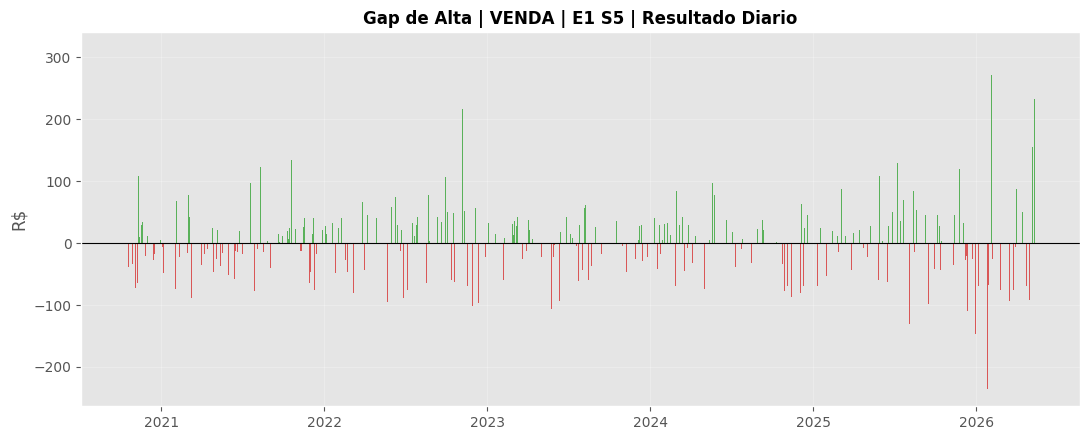

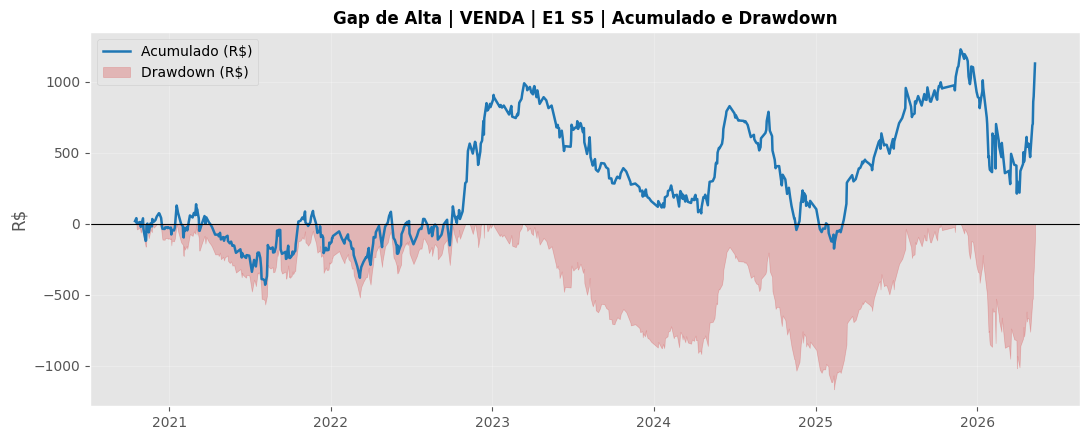

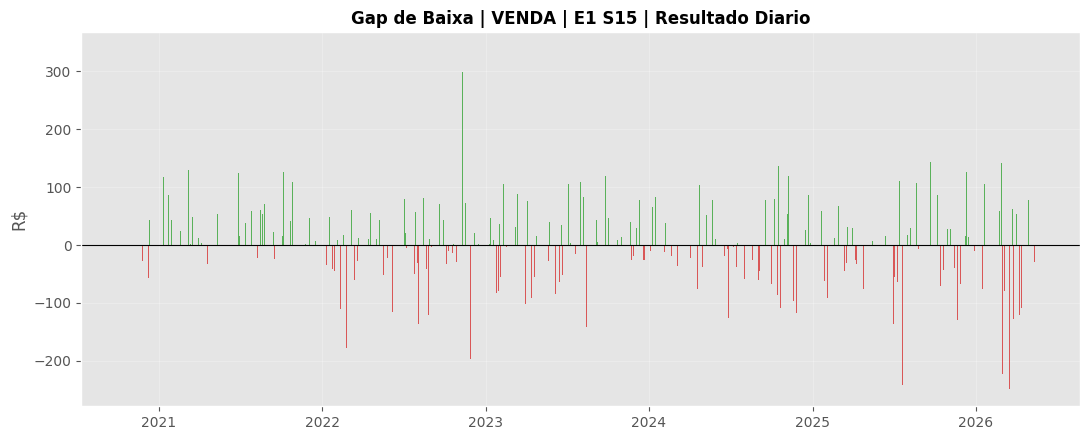

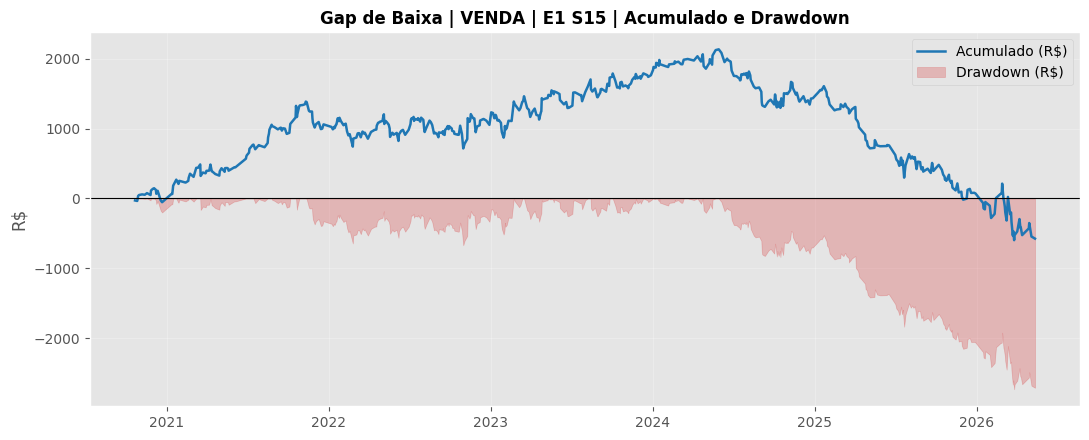


6) Resumo diario dos melhores setups unicos (R$)


,tipo_gap,lado,entrada_min,saida_min,Dias Operados,Media Dia (R$),Mediana Dia (R$),Melhor Dia (R$),Pior Dia (R$),Dias Positivos (%),Dias Negativos (%),Resultado Final (R$),Max Drawdown (R$)
0,Gap de Alta,venda,1,5,645,1.75,1.0,313.0,-236.0,50.2,48.8,1130.0,-1164.0
1,Gap de Baixa,venda,1,15,550,-1.05,0.0,338.0,-249.0,49.8,49.6,-575.0,-2731.0


7) Sazonalidade mensal (R$) dos melhores setups unicos


,tipo_gap,mes,resultado_mes_rs
0,Gap de Alta,2020-10,-20.0
1,Gap de Alta,2020-11,35.0
2,Gap de Alta,2020-12,-39.0
3,Gap de Alta,2021-01,25.0
4,Gap de Alta,2021-02,77.0
5,Gap de Alta,2021-03,-31.0
6,Gap de Alta,2021-04,-156.0
7,Gap de Alta,2021-05,-43.0
8,Gap de Alta,2021-06,-67.0
9,Gap de Alta,2021-07,-169.0


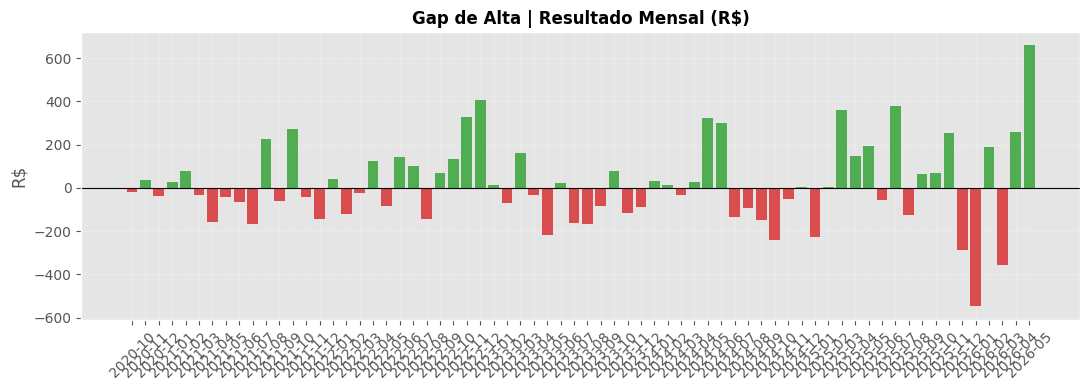

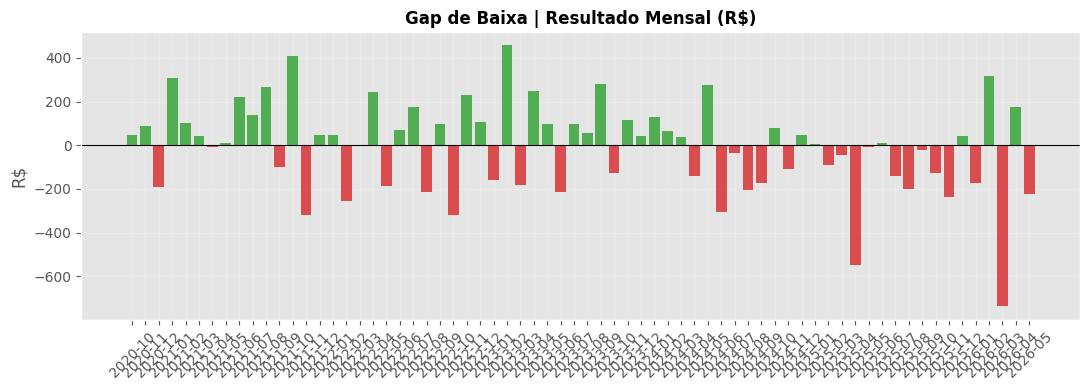

CSVs exportados em: C:\Users\rodrigo.silva\Pictures\UFG\DB FIN\outputs_gap_win


In [117]:
# 3) Resumos organizados para visualizacao
resumo_cenario, melhor_por_faixa, resumo_gap_alta, resumo_gap_baixa = resumir_simulacao(
    trades_sim,
    n_contratos=N_CONTRATOS,
)

resumo_gap_alta_visual = tabela_visual_simulador(resumo_gap_alta)
resumo_gap_baixa_visual = tabela_visual_simulador(resumo_gap_baixa)
resumo_gap_alta_unico = tabela_visual_simulador(resumo_gap_alta, compactar=True)
resumo_gap_baixa_unico = tabela_visual_simulador(resumo_gap_baixa, compactar=True)
melhor_por_faixa_visual = selecionar_colunas_simulador(
    formatar_tabela_apresentacao_simulador(
        melhor_por_faixa.sort_values(['tipo_gap', 'faixa_gap', 'Quantidade Trades', 'Resultado Total (pts)'], ascending=[True, True, False, False])
    )
)

print('1) Melhor setup por faixa de gap')
display(melhor_por_faixa_visual.reset_index(drop=True))

print('2) Top 15 - Gap de Alta (setups unicos por entrada)')
display(resumo_gap_alta_unico.head(15))

print('3) Top 15 - Gap de Baixa (setups unicos por entrada)')
display(resumo_gap_baixa_unico.head(15))

print('4) Ranking sem saidas redundantes - Gap de Alta')
display(resumo_gap_alta_visual.head(20))

print('5) Ranking sem saidas redundantes - Gap de Baixa')
display(resumo_gap_baixa_visual.head(20))

# 4) Serie diaria em R$ do melhor setup unico de Alta e de Baixa
series_diarias = []
resumos_diarios = []

resumo_cenario_unico = compactar_setup_simulador(resumo_cenario)

for tipo in ['Gap de Alta', 'Gap de Baixa']:
    top = ordenar_resumo_simulador(resumo_cenario_unico[resumo_cenario_unico['tipo_gap'] == tipo]).head(1)
    if top.empty:
        continue

    r = top.iloc[0]
    lado = r['lado']
    ent = int(r['entrada_min'])
    sai = int(r['saida_min'])

    calendario_tipo = base_gap_sim.loc[base_gap_sim['tipo_gap'] == tipo, 'session_date'].dropna().tolist()
    diario = construir_serie_diaria(
        trades_sim,
        tipo_gap=tipo,
        lado=lado,
        entrada_min=ent,
        saida_min=sai,
        n_contratos=N_CONTRATOS,
        calendario_datas=calendario_tipo,
    )

    if diario.empty:
        continue

    diario['tipo_gap'] = tipo
    diario['lado'] = lado
    diario['entrada_min'] = ent
    diario['saida_min'] = sai
    series_diarias.append(diario)

    resumo_d = pd.Series({
        'tipo_gap': tipo,
        'lado': lado,
        'entrada_min': ent,
        'saida_min': sai,
        'Dias Operados': int(len(diario)),
        'Media Dia (R$)': round(diario['resultado_dia_rs'].mean(), 2),
        'Mediana Dia (R$)': round(diario['resultado_dia_rs'].median(), 2),
        'Melhor Dia (R$)': round(diario['resultado_dia_rs'].max(), 2),
        'Pior Dia (R$)': round(diario['resultado_dia_rs'].min(), 2),
        'Dias Positivos (%)': round((diario['resultado_dia_rs'] > 0).mean() * 100, 1),
        'Dias Negativos (%)': round((diario['resultado_dia_rs'] < 0).mean() * 100, 1),
        'Resultado Final (R$)': round(diario['acumulado_rs'].iloc[-1], 2),
        'Max Drawdown (R$)': round(diario['drawdown_rs'].min(), 2),
    })
    resumos_diarios.append(resumo_d)

    plot_resultado_diario_moeda(diario, f"{tipo} | {lado.upper()} | E{ent} S{sai} | Resultado Diario")
    plot_acumulado_drawdown_moeda(diario, f"{tipo} | {lado.upper()} | E{ent} S{sai} | Acumulado e Drawdown")

if series_diarias:
    serie_diaria_melhores = pd.concat(series_diarias, ignore_index=True)
else:
    serie_diaria_melhores = pd.DataFrame()

if resumos_diarios:
    resumo_diario_melhores = pd.DataFrame(resumos_diarios)
    print()
    print('6) Resumo diario dos melhores setups unicos (R$)')
    display(resumo_diario_melhores)
else:
    resumo_diario_melhores = pd.DataFrame()

# 5) Sazonalidade mensal (R$) dos melhores setups
print('7) Sazonalidade mensal (R$) dos melhores setups unicos')
if not serie_diaria_melhores.empty:
    base_mes = serie_diaria_melhores.copy()
    base_mes['mes'] = pd.to_datetime(base_mes['session_date']).dt.to_period('M').astype(str)
    saz_mensal = (
        base_mes.groupby(['tipo_gap', 'mes'], as_index=False)
        .agg(resultado_mes_rs=('resultado_dia_rs', 'sum'))
    )
    display(saz_mensal.head(24))

    for tipo in saz_mensal['tipo_gap'].unique():
        sub = saz_mensal[saz_mensal['tipo_gap'] == tipo].copy()
        fig, ax = plt.subplots(figsize=(11, 4))
        cores = np.where(sub['resultado_mes_rs'] >= 0, '#2ca02c', '#d62728')
        ax.bar(sub['mes'], sub['resultado_mes_rs'], color=cores, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f'{tipo} | Resultado Mensal (R$)', fontsize=12, fontweight='bold')
        ax.set_ylabel('R$')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
else:
    saz_mensal = pd.DataFrame()

# 6) Exportacao
formatar_tabela_apresentacao_simulador(resumo_cenario).to_csv(PASTA_SAIDA / 'simulador_tempo_puro_resumo_cenarios.csv', index=False, encoding='utf-8-sig')
tabela_visual_simulador(resumo_cenario, compactar=True).to_csv(PASTA_SAIDA / 'simulador_tempo_puro_resumo_cenarios_unicos.csv', index=False, encoding='utf-8-sig')
melhor_por_faixa_visual.to_csv(PASTA_SAIDA / 'simulador_tempo_puro_melhor_por_faixa.csv', index=False, encoding='utf-8-sig')
resumo_gap_alta_visual.to_csv(PASTA_SAIDA / 'simulador_tempo_puro_gap_alta.csv', index=False, encoding='utf-8-sig')
resumo_gap_baixa_visual.to_csv(PASTA_SAIDA / 'simulador_tempo_puro_gap_baixa.csv', index=False, encoding='utf-8-sig')
trades_sim.to_csv(PASTA_SAIDA / 'simulador_tempo_puro_trades.csv', index=False, encoding='utf-8-sig')

if not serie_diaria_melhores.empty:
    serie_diaria_melhores.to_csv(PASTA_SAIDA / 'simulador_serie_diaria_melhores.csv', index=False, encoding='utf-8-sig')
if not resumo_diario_melhores.empty:
    resumo_diario_melhores.to_csv(PASTA_SAIDA / 'simulador_resumo_diario_melhores.csv', index=False, encoding='utf-8-sig')
if 'saz_mensal' in globals() and isinstance(saz_mensal, pd.DataFrame) and not saz_mensal.empty:
    saz_mensal.to_csv(PASTA_SAIDA / 'simulador_sazonalidade_mensal.csv', index=False, encoding='utf-8-sig')

print(f"CSVs exportados em: {PASTA_SAIDA.resolve()}")


## 9. Simulador 3 (Operar Contra/A Favor do Gap, Contexto, Treino/Teste)

Escopo desta etapa:
- comparar operar contra o gap vs operar a favor do gap;
- usar stop/target por volatilidade (desvio padr?o intraday);
- aplicar filtros de contexto (faixa de gap, volume de abertura, pre-close forte/fraco);
- analisar por dia da semana;
- validar em treino/teste por ordem temporal, sem misturar passado e futuro.



In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _dia_semana_pt(dt):
    mapa = {0:'Segunda',1:'Terca',2:'Quarta',3:'Quinta',4:'Sexta'}
    return mapa.get(pd.to_datetime(dt).weekday(), 'Outro')


def _forca_preclose(row):
    # Usa colunas ja criadas na base_ml/base_gap quando disponivel; fallback neutro.
    for c in ['preclose_return','preclose_slope_points_per_min','preclose_close_position_window']:
        if c not in row.index:
            return 'Neutro'
    score = 0
    score += np.sign(row.get('preclose_return',0))
    score += np.sign(row.get('preclose_slope_points_per_min',0))
    pos = row.get('preclose_close_position_window',0.5)
    score += 1 if pos>0.66 else (-1 if pos<0.34 else 0)
    if score >= 2:
        return 'Forte'
    if score <= -2:
        return 'Fraco'
    return 'Neutro'


def preparar_base_v3(base_intraday, base_gap, minutos_open_vol=15, passo_faixa=100, gap_min=0):
    intra = base_intraday.copy().sort_values(['session_date','datetime'])
    if 'session_date' not in intra.columns:
        intra = intra.reset_index()
    intra['session_date'] = pd.to_datetime(intra['session_date'])
    intra['datetime'] = pd.to_datetime(intra['datetime'])
    intra['minuto_sessao'] = intra.groupby('session_date').cumcount()

    gap = base_gap.copy()
    if 'session_date' not in gap.columns:
        gap = gap.reset_index()
    gap['session_date'] = pd.to_datetime(gap['session_date'])
    gap = gap[gap['gap_abs'].abs() >= gap_min].copy()

    # faixa dinamica 100/100 etc
    max_gap = max(gap['gap_abs'].abs().max(), passo_faixa)
    bins = np.arange(0, int(np.ceil(max_gap/passo_faixa)*passo_faixa)+passo_faixa, passo_faixa)
    if len(bins)<2:
        bins=np.array([0,passo_faixa])
    labels=[f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    gap['faixa_gap'] = pd.cut(gap['gap_abs'].abs(), bins=bins, labels=labels, include_lowest=True).astype(str)

    # features de regime por dia
    feats=[]
    for d, df in intra.groupby('session_date', sort=False):
        df=df.sort_values('datetime')
        opn=float(df.iloc[0]['open'])
        ret1m = (float(df.iloc[1]['close'])/opn - 1) if len(df)>1 else 0
        janela = df[df['minuto_sessao']<=minutos_open_vol]
        vol_open = float(janela['volume'].sum()) if 'volume' in janela.columns else float(janela['tick_volume'].sum())
        std_open = float(janela['close'].pct_change().dropna().std()) if len(janela)>2 else 0.0
        feats.append({'session_date':d,'volume_abertura':vol_open,'std_abertura':std_open,'ret1m':ret1m,'dia_semana':_dia_semana_pt(d)})
    feats=pd.DataFrame(feats)
    gap=gap.merge(feats,on='session_date',how='left')

    # quartis de volume
    q1,q3 = gap['volume_abertura'].quantile([0.25,0.75]).values
    gap['volume_abertura'] = np.where(gap['volume_abertura']>=q3,'Alto',np.where(gap['volume_abertura']<=q1,'Baixo','Medio'))

    # preclose forte/fraco
    gap['forca_preclose'] = gap.apply(_forca_preclose, axis=1)

    intra_dict = {d:g.sort_values('datetime') for d,g in intra.groupby('session_date', sort=False)}
    return intra_dict, gap


def simular_fade_breakout(intra_dict, gap_df, entradas=[2,5], saidas=[15,30], stop_k=1.0, alvo_k=1.5, custo_pts=0):
    regs=[]
    for _,r in gap_df.iterrows():
        d=r['session_date']; g=float(r['gap_abs'])
        dd=intra_dict.get(pd.to_datetime(d))
        if dd is None or dd.empty:
            continue
        opn=float(r['open'])
        std_ref = max(float(r.get('std_abertura',0.0))*opn, 1.0)
        # volatilidade em pontos aprox
        risco_pts = std_ref * stop_k
        alvo_pts = std_ref * alvo_k

        for modo in ['Operar contra o gap','Operar a favor do gap']:
            # direcao por gap
            if g>0:
                lado = 'venda' if modo=='Operar contra o gap' else 'compra'
            elif g<0:
                lado = 'compra' if modo=='Operar contra o gap' else 'venda'
            else:
                continue

            for e in entradas:
                ent=dd[dd['minuto_sessao']>=e].head(1)
                if ent.empty: continue
                pe=float(ent.iloc[0]['open'])

                for s in saidas:
                    if s<=e: continue
                    win=dd[(dd['minuto_sessao']>=e)&(dd['minuto_sessao']<=s)]
                    if win.empty: continue
                    stop = pe-risco_pts if lado=='compra' else pe+risco_pts
                    alvo = pe+alvo_pts if lado=='compra' else pe-alvo_pts
                    ps=float(win.iloc[-1]['close']); motivo='Tempo'

                    for _,b in win.iterrows():
                        lo=float(b['low']); hi=float(b['high'])
                        bate_stop = (lo<=stop) if lado=='compra' else (hi>=stop)
                        bate_alvo = (hi>=alvo) if lado=='compra' else (lo<=alvo)
                        if bate_stop and bate_alvo:
                            bate_stop=True; bate_alvo=False
                        if bate_stop:
                            ps=stop; motivo='Stop'; break
                        if bate_alvo:
                            ps=alvo; motivo='Alvo'; break

                    bruto=(ps-pe) if lado=='compra' else (pe-ps)
                    liq=bruto-custo_pts
                    regs.append({
                        'session_date':d,'dia_semana':r['dia_semana'],'estrategia':modo,'tipo_gap':'Alta' if g>0 else 'Baixa',
                        'faixa_gap':r['faixa_gap'],'volume_abertura':r['volume_abertura'],'forca_preclose':r['forca_preclose'],
                        'entrada_min':e,'saida_min':s,'lado':lado,'motivo_saida':motivo,
                        'stop_pts':risco_pts,'alvo_pts':alvo_pts,
                        'resultado_pts':liq,'resultado_rs':liq*0.20
                    })
    return pd.DataFrame(regs)


def resumir_v3(trades):
    if trades.empty:
        return pd.DataFrame()
    grp=['estrategia','tipo_gap','faixa_gap','volume_abertura','forca_preclose','dia_semana','entrada_min','saida_min','lado']
    t=trades.groupby(grp).agg(
        quantidade=('resultado_pts','size'),
        acerto_pct=('resultado_pts',lambda s:(s>0).mean()*100),
        media_pts=('resultado_pts','mean'),
        total_pts=('resultado_pts','sum'),
        media_rs=('resultado_rs','mean'),
        total_rs=('resultado_rs','sum'),
        ganhos_total_rs=('resultado_rs',lambda s:s[s>0].sum()),
        perdas_total_rs=('resultado_rs',lambda s:abs(s[s<0].sum())),
        stop_medio_pts=('stop_pts','mean'),
        alvo_medio_pts=('alvo_pts','mean'),
        alvo_pct=('motivo_saida',lambda s:(s=='Alvo').mean()*100),
        stop_pct=('motivo_saida',lambda s:(s=='Stop').mean()*100),
        tempo_pct=('motivo_saida',lambda s:(s=='Tempo').mean()*100),
        ganho_medio_pts=('resultado_pts',lambda s:s[s>0].mean() if (s>0).any() else 0),
        perda_media_pts=('resultado_pts',lambda s:abs(s[s<0].mean()) if (s<0).any() else 0),
        fator_lucro=('resultado_pts',lambda s:(s[s>0].sum()/abs(s[s<0].sum())) if (s<0).any() else np.nan)
    ).reset_index()
    t['payoff']=np.where(t['perda_media_pts']>0,t['ganho_medio_pts']/t['perda_media_pts'],np.nan)
    return t.sort_values(['quantidade','total_pts','fator_lucro','acerto_pct'],ascending=[False,False,False,False])


COLUNAS_VISUAIS_V3 = [
    'estrategia', 'tipo_gap', 'faixa_gap', 'volume_abertura', 'forca_preclose', 'dia_semana',
    'entrada_min', 'saida_min', 'lado',
    'quantidade', 'acerto_pct',
    'total_rs', 'media_rs', 'ganhos_total_rs', 'perdas_total_rs',
    'total_pts', 'media_pts',
    'alvo_medio_pts', 'stop_medio_pts', 'alvo_pct', 'stop_pct', 'tempo_pct',
    'payoff', 'fator_lucro',
    'ganho_medio_pts', 'perda_media_pts',
]


def selecionar_colunas_v3(df):
    cols = [c for c in COLUNAS_VISUAIS_V3 if c in df.columns]
    extras = [c for c in df.columns if c not in cols]
    return df[cols + extras].copy()


def ordenar_resumo_v3(df):
    if df.empty:
        return df.copy()
    out = df.copy()
    sort_cols = [c for c in ['total_rs', 'quantidade', 'acerto_pct', 'media_rs', 'saida_min'] if c in out.columns]
    ascending = [False, False, False, False, True][:len(sort_cols)]
    return out.sort_values(sort_cols, ascending=ascending).reset_index(drop=True) if sort_cols else out


def remover_saidas_redundantes_v3(df):
    if df.empty:
        return df.copy()
    chaves_setup = [
        c for c in [
            'estrategia', 'tipo_gap', 'faixa_gap', 'volume_abertura', 'forca_preclose',
            'dia_semana', 'entrada_min', 'lado'
        ]
        if c in df.columns
    ]
    chaves_resultado = [
        c for c in [
            'quantidade', 'acerto_pct', 'media_pts', 'total_pts', 'media_rs', 'total_rs',
            'ganhos_total_rs', 'perdas_total_rs', 'alvo_pct', 'stop_pct', 'tempo_pct',
            'payoff', 'fator_lucro', 'ganho_medio_pts', 'perda_media_pts',
        ]
        if c in df.columns
    ]
    chaves = chaves_setup + chaves_resultado
    if not chaves:
        return ordenar_resumo_v3(df)
    ordenado = df.sort_values(['saida_min'] if 'saida_min' in df.columns else chaves).copy()
    return ordenado.drop_duplicates(subset=chaves, keep='first').reset_index(drop=True)


def compactar_setup_v3(df):
    if df.empty:
        return df.copy()
    chaves = [
        c for c in [
            'estrategia', 'tipo_gap', 'faixa_gap', 'volume_abertura', 'forca_preclose',
            'dia_semana', 'entrada_min', 'lado'
        ]
        if c in df.columns
    ]
    ordenado = ordenar_resumo_v3(remover_saidas_redundantes_v3(df))
    return ordenado.groupby(chaves, as_index=False).head(1).reset_index(drop=True) if chaves else ordenado


def formatar_tabela_apresentacao_v3(df):
    if df.empty:
        return df.copy()
    out = df.drop(columns=['exp100_pts'], errors='ignore').copy()
    for col in [c for c in out.columns if c.endswith('_pct') or '(%)' in c]:
        out[col] = pd.to_numeric(out[col], errors='coerce').round(2)
    for col in [c for c in out.columns if c.endswith('_pts') or c.endswith('_rs')]:
        out[col] = pd.to_numeric(out[col], errors='coerce').round(2)
    for col in ['payoff', 'fator_lucro']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce').round(2)
    for col in ['payoff', 'fator_lucro']:
        if col in out.columns:
            valores = pd.to_numeric(out[col], errors='coerce')
            sem_perdas = out[col].isna() | np.isinf(valores)
            out[col] = out[col].mask(sem_perdas, 'Sem perdas')
    return selecionar_colunas_v3(out)


def tabela_visual_v3(df, compactar=False, remover_redundantes=True):
    base = df.copy()
    if remover_redundantes:
        base = remover_saidas_redundantes_v3(base)
    base = compactar_setup_v3(base) if compactar else ordenar_resumo_v3(base)
    return formatar_tabela_apresentacao_v3(base)


def walk_forward_split(gap_df, train_frac=0.7):
    dias=sorted(gap_df['session_date'].dropna().unique())
    k=max(1,int(len(dias)*train_frac))
    train=set(dias[:k]); test=set(dias[k:])
    return train,test


def plot_barras_mensal(trades, titulo='Resultado mensal (R$)'):
    if trades.empty: return
    d=trades.copy(); d['mes']=pd.to_datetime(d['session_date']).dt.to_period('M').astype(str)
    m=d.groupby(['mes','estrategia'])['resultado_rs'].sum().reset_index()
    piv=m.pivot(index='mes',columns='estrategia',values='resultado_rs').fillna(0)
    ax=piv.plot(kind='bar',figsize=(12,4),title=titulo)
    ax.axhline(0,color='black',lw=0.8)
    plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()


def construir_serie_diaria_setup_v3(trades, setup):
    if trades.empty or setup is None:
        return pd.DataFrame()
    sub = trades.copy()
    for col in ['estrategia','tipo_gap','faixa_gap','volume_abertura','forca_preclose','dia_semana','entrada_min','saida_min','lado']:
        if col in setup.index and col in sub.columns:
            sub = sub[sub[col] == setup[col]]
    if sub.empty:
        return pd.DataFrame()
    diario = (
        sub.groupby('session_date', as_index=False)
        .agg(
            resultado_dia_rs=('resultado_rs','sum'),
            resultado_dia_pts=('resultado_pts','sum'),
            trades_dia=('resultado_rs','size'),
            acerto_dia_pct=('resultado_rs',lambda s:(s>0).mean()*100),
        )
        .sort_values('session_date')
    )
    diario['acumulado_rs'] = diario['resultado_dia_rs'].cumsum()
    diario['pico_rs'] = diario['acumulado_rs'].cummax()
    diario['drawdown_rs'] = diario['acumulado_rs'] - diario['pico_rs']
    return diario


def plot_acumulado_setup_v3(diario, titulo):
    if diario.empty:
        return
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(diario['session_date'], diario['acumulado_rs'], lw=2, label='Acumulado (R$)')
    ax.fill_between(diario['session_date'], diario['drawdown_rs'], 0, color='#d62728', alpha=0.25, label='Drawdown (R$)')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(titulo)
    ax.set_ylabel('R$')
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()


def plot_linha_pontos_trade(trades, titulo='Linha continua de pontos por trade'):
    if trades.empty: return
    d=trades.sort_values('session_date').reset_index(drop=True).copy()
    d['acum_pts']=d['resultado_pts'].cumsum()
    fig,ax=plt.subplots(figsize=(12,4))
    ax.plot(d.index,d['resultado_pts'],alpha=0.4,label='Resultado por trade (pts)')
    ax.plot(d.index,d['acum_pts'],lw=2,label='Acumulado (pts)')
    ax.axhline(0,color='black',lw=0.8)
    ax.set_title(titulo); ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()



Filtro do ranking: minimo de 10 trades por setup
1) Top teste - setups unicos por entrada/contexto


,estrategia,tipo_gap,faixa_gap,volume_abertura,forca_preclose,dia_semana,entrada_min,saida_min,lado,quantidade,acerto_pct,total_rs,media_rs,ganhos_total_rs,perdas_total_rs,total_pts,media_pts,alvo_medio_pts,stop_medio_pts,alvo_pct,stop_pct,tempo_pct,payoff,fator_lucro,ganho_medio_pts,perda_media_pts
0,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,2,5,venda,11,72.73,183.29,16.66,228.24,44.96,916.43,83.31,134.4,89.6,72.73,27.27,0.0,1.90,5.08,142.65,74.93
1,Operar contra o gap,Baixa,150-300,Alto,Neutro,Terca,5,10,compra,11,54.55,104.52,9.50,180.98,76.46,522.59,47.51,134.4,89.6,54.55,45.45,0.0,1.97,2.37,150.82,76.46
2,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,1,5,venda,11,45.45,80.33,7.30,166.47,86.14,401.64,36.51,134.4,89.6,45.45,54.55,0.0,2.32,1.93,166.47,71.78
3,Operar contra o gap,Baixa,150-300,Alto,Neutro,Terca,10,15,compra,11,54.55,34.94,3.18,139.24,104.29,174.72,15.88,134.4,89.6,54.55,45.45,0.0,1.11,1.34,116.03,104.29
4,Operar contra o gap,Baixa,150-300,Alto,Neutro,Terca,3,5,compra,11,36.36,32.89,2.99,138.00,105.11,164.45,14.95,134.4,89.6,36.36,63.64,0.0,2.30,1.31,172.50,75.08
5,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,10,15,venda,11,36.36,14.33,1.30,126.87,112.54,71.67,6.52,134.4,89.6,36.36,63.64,0.0,1.97,1.13,158.59,80.38
6,Operar contra o gap,Baixa,150-300,Alto,Neutro,Terca,1,5,compra,11,36.36,-28.66,-2.61,101.07,129.73,-143.31,-13.03,134.4,89.6,36.36,63.64,0.0,1.36,0.78,126.34,92.67
7,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,3,5,venda,11,18.18,-99.35,-9.03,58.66,158.01,-496.75,-45.16,134.4,89.6,18.18,81.82,0.0,1.67,0.37,146.65,87.78
8,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,5,10,venda,11,18.18,-100.80,-9.16,57.79,158.59,-504.01,-45.82,134.4,89.6,18.18,81.82,0.0,1.64,0.36,144.47,88.11
9,Operar contra o gap,Baixa,150-300,Alto,Neutro,Terca,2,5,compra,11,0.00,-197.12,-17.92,0.00,197.12,-985.58,-89.60,134.4,89.6,0.00,100.00,0.0,0.00,0.00,0.00,89.60


2) Top treino - setups unicos por entrada/contexto


,estrategia,tipo_gap,faixa_gap,volume_abertura,forca_preclose,dia_semana,entrada_min,saida_min,lado,quantidade,acerto_pct,total_rs,media_rs,ganhos_total_rs,perdas_total_rs,total_pts,media_pts,alvo_medio_pts,stop_medio_pts,alvo_pct,stop_pct,tempo_pct,payoff,fator_lucro,ganho_medio_pts,perda_media_pts
0,Operar contra o gap,Alta,150-300,Medio,Neutro,Quarta,5,20,venda,15,66.67,164.01,10.93,243.72,79.72,820.03,54.67,121.10,80.73,66.67,33.33,0.00,1.53,3.06,121.86,79.72
1,Operar contra o gap,Alta,150-300,Medio,Neutro,Quarta,3,20,venda,15,60.00,145.13,9.68,232.39,87.27,725.64,48.38,121.10,80.73,60.00,40.00,0.00,1.78,2.66,129.11,72.72
2,Operar a favor do gap,Alta,150-300,Medio,Neutro,Quinta,10,30,compra,17,64.71,142.62,8.39,225.84,83.22,713.09,41.95,103.14,68.76,64.71,35.29,0.00,1.48,2.71,102.65,69.35
3,Operar contra o gap,Baixa,150-300,Medio,Neutro,Terca,2,5,compra,11,72.73,132.39,12.04,154.36,21.98,661.94,60.18,85.15,56.77,72.73,27.27,0.00,2.63,7.02,96.48,36.63
4,Operar contra o gap,Baixa,150-300,Medio,Neutro,Quinta,5,10,compra,10,70.00,127.91,12.79,171.44,43.53,639.53,63.95,118.37,78.91,70.00,30.00,0.00,1.69,3.94,122.45,72.55
5,Operar contra o gap,Alta,150-300,Medio,Neutro,Sexta,5,10,venda,14,57.14,123.11,8.79,194.73,71.61,615.57,43.97,107.91,71.94,57.14,42.86,0.00,2.04,2.72,121.70,59.68
6,Operar contra o gap,Alta,450-600,Medio,Neutro,Segunda,3,5,venda,12,58.33,115.89,9.66,185.26,69.37,579.45,48.29,120.55,80.37,58.33,41.67,0.00,1.91,2.67,132.33,69.37
7,Operar contra o gap,Alta,150-300,Medio,Neutro,Quarta,10,30,venda,15,53.33,112.39,7.49,210.14,97.75,561.95,37.46,121.10,80.73,53.33,40.00,6.67,1.88,2.15,131.34,69.82
8,Operar contra o gap,Alta,450-600,Medio,Neutro,Segunda,2,5,venda,12,58.33,104.25,8.69,178.28,74.02,521.27,43.44,120.55,80.37,58.33,41.67,0.00,1.72,2.41,127.34,74.02
9,Operar a favor do gap,Alta,150-300,Medio,Neutro,Sexta,1,5,compra,14,50.00,98.78,7.06,180.13,81.35,493.89,35.28,107.91,71.94,50.00,50.00,0.00,2.21,2.21,128.66,58.11


3) Ranking sem saidas redundantes do teste


...

,estrategia,tipo_gap,faixa_gap,volume_abertura,forca_preclose,dia_semana,entrada_min,saida_min,lado,quantidade,acerto_pct,total_rs,media_rs,ganhos_total_rs,perdas_total_rs,total_pts,media_pts,alvo_medio_pts,stop_medio_pts,alvo_pct,stop_pct,tempo_pct,payoff,fator_lucro,ganho_medio_pts,perda_media_pts
0,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,2,5,venda,11,72.73,183.29,16.66,228.24,44.96,916.43,83.31,134.4,89.6,72.73,27.27,0.0,1.9,5.08,142.65,74.93


6) Dia da semana


,dia_semana,estrategia,quantidade,media_rs,total_rs
5,Segunda,Operar contra o gap,5588,0.39,2179.18
8,Terca,Operar a favor do gap,5148,0.34,1738.47
1,Quarta,Operar contra o gap,5192,0.03,143.74
7,Sexta,Operar contra o gap,5082,-0.11,-572.77
2,Quinta,Operar a favor do gap,5280,-0.25,-1336.52
0,Quarta,Operar a favor do gap,5192,-0.74,-3823.14
9,Terca,Operar contra o gap,5148,-0.85,-4363.37
3,Quinta,Operar contra o gap,5280,-1.55,-8166.84
4,Segunda,Operar a favor do gap,5588,-1.66,-9262.60
6,Sexta,Operar a favor do gap,5082,-2.97,-15088.39


7) Curva do melhor setup do teste em R$


,estrategia,tipo_gap,faixa_gap,volume_abertura,forca_preclose,dia_semana,entrada_min,saida_min,lado,resultado_final_rs,max_drawdown_rs,dias_operados
0,Operar a favor do gap,Baixa,150-300,Alto,Neutro,Terca,2,5,venda,214.61,-22.9,14


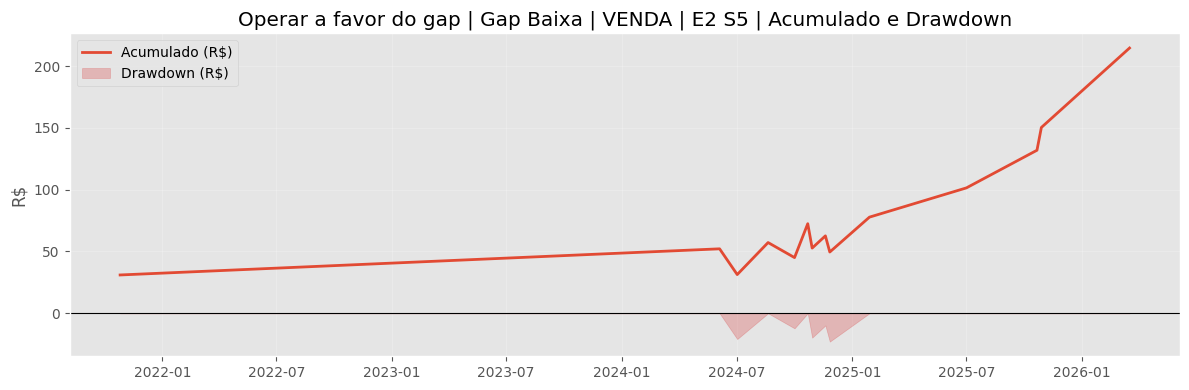

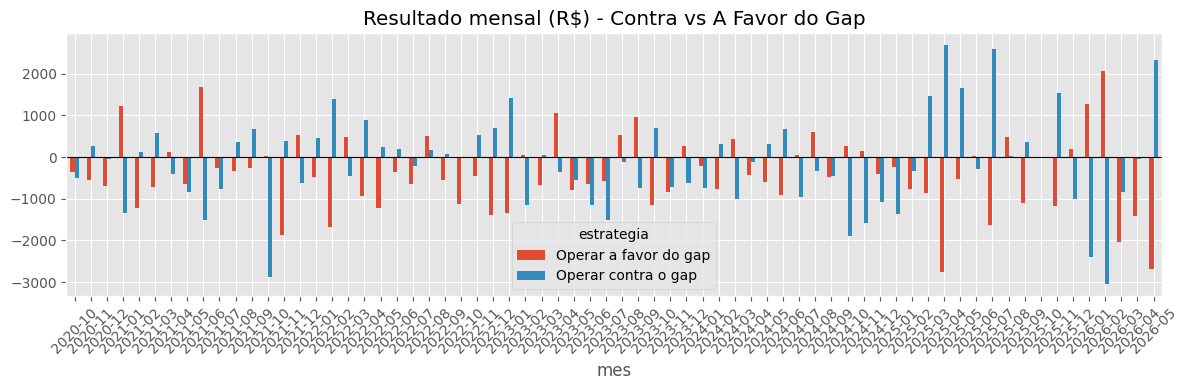

In [119]:
# PARAMETROS - alterar aqui
PASSO_FAIXA_GAP = 150
GAP_MINIMO = 100
ENTRADAS = [1,2,3,5,10]
SAIDAS = [5,10,15,20,30]
STOP_K_STD = 1.0
ALVO_K_STD = 1.5
CUSTO_PTS = 0
TRAIN_FRAC = 0.7
MIN_TRADES_RANKING = 10

intra_dict_v3, base_v3 = preparar_base_v3(
    base_intraday, base_gap,
    minutos_open_vol=15,
    passo_faixa=PASSO_FAIXA_GAP,
    gap_min=GAP_MINIMO
)

trades_v3 = simular_fade_breakout(
    intra_dict_v3, base_v3,
    entradas=ENTRADAS,
    saidas=SAIDAS,
    stop_k=STOP_K_STD,
    alvo_k=ALVO_K_STD,
    custo_pts=CUSTO_PTS
)

train_days, test_days = walk_forward_split(base_v3, TRAIN_FRAC)
resumo_train = resumir_v3(trades_v3[trades_v3['session_date'].isin(train_days)])
resumo_test = resumir_v3(trades_v3[trades_v3['session_date'].isin(test_days)])

resumo_train_rank = resumo_train[resumo_train['quantidade'] >= MIN_TRADES_RANKING].copy()
resumo_test_rank = resumo_test[resumo_test['quantidade'] >= MIN_TRADES_RANKING].copy()

resumo_train_visual = tabela_visual_v3(resumo_train_rank)
resumo_test_visual = tabela_visual_v3(resumo_test_rank)
resumo_train_unico = tabela_visual_v3(resumo_train_rank, compactar=True)
resumo_test_unico = tabela_visual_v3(resumo_test_rank, compactar=True)

print(f'Filtro do ranking: minimo de {MIN_TRADES_RANKING} trades por setup')
print('1) Top teste - setups unicos por entrada/contexto')
display(resumo_test_unico.head(20))

print('2) Top treino - setups unicos por entrada/contexto')
display(resumo_train_unico.head(20))

print('3) Ranking sem saidas redundantes do teste')
display(resumo_test_visual.head(25))

print('4) Ranking sem saidas redundantes do treino')
display(resumo_train_visual.head(25))

# melhores por faixa (alta/baixa) no teste, usando setups unicos e minimo de amostra
melhor_faixa_teste = (
    compactar_setup_v3(resumo_test_rank)
    .sort_values(['tipo_gap','faixa_gap','total_rs','quantidade','acerto_pct','media_rs','saida_min'], ascending=[True,True,False,False,False,False,True])
    .groupby(['tipo_gap','faixa_gap'], as_index=False)
    .head(1)
    .reset_index(drop=True)
)
melhor_faixa_teste_visual = formatar_tabela_apresentacao_v3(melhor_faixa_teste)
print('5) Melhor setup unico por faixa no teste')
display(melhor_faixa_teste_visual)

# dia da semana
dia_semana_rank = (
    trades_v3.groupby(['dia_semana','estrategia'])['resultado_rs']
    .agg(quantidade='count', media_rs='mean', total_rs='sum')
    .reset_index()
    .sort_values(['total_rs', 'quantidade'], ascending=[False, False])
)
dia_semana_rank[['media_rs','total_rs']] = dia_semana_rank[['media_rs','total_rs']].round(2)
print('6) Dia da semana')
display(dia_semana_rank)

# curva correta: um setup selecionado, nao todos os trades simulados juntos
setup_plot = compactar_setup_v3(resumo_test_rank).sort_values(['total_rs','quantidade','acerto_pct'], ascending=[False,False,False]).head(1)
if not setup_plot.empty:
    setup_plot = setup_plot.iloc[0]
    serie_setup_v3 = construir_serie_diaria_setup_v3(trades_v3, setup_plot)
    resumo_setup_v3 = pd.DataFrame([{
        'estrategia': setup_plot['estrategia'],
        'tipo_gap': setup_plot['tipo_gap'],
        'faixa_gap': setup_plot['faixa_gap'],
        'volume_abertura': setup_plot['volume_abertura'],
        'forca_preclose': setup_plot['forca_preclose'],
        'dia_semana': setup_plot['dia_semana'],
        'entrada_min': setup_plot['entrada_min'],
        'saida_min': setup_plot['saida_min'],
        'lado': setup_plot['lado'],
        'resultado_final_rs': round(serie_setup_v3['acumulado_rs'].iloc[-1], 2) if not serie_setup_v3.empty else 0,
        'max_drawdown_rs': round(serie_setup_v3['drawdown_rs'].min(), 2) if not serie_setup_v3.empty else 0,
        'dias_operados': int((serie_setup_v3['trades_dia'] > 0).sum()) if not serie_setup_v3.empty else 0,
    }])
    print('7) Curva do melhor setup do teste em R$')
    display(resumo_setup_v3)
    titulo = f"{setup_plot['estrategia']} | Gap {setup_plot['tipo_gap']} | {setup_plot['lado'].upper()} | E{int(setup_plot['entrada_min'])} S{int(setup_plot['saida_min'])} | Acumulado e Drawdown"
    plot_acumulado_setup_v3(serie_setup_v3, titulo)
else:
    serie_setup_v3 = pd.DataFrame()
    resumo_setup_v3 = pd.DataFrame()

plot_barras_mensal(trades_v3, 'Resultado mensal (R$) - Contra vs A Favor do Gap')
